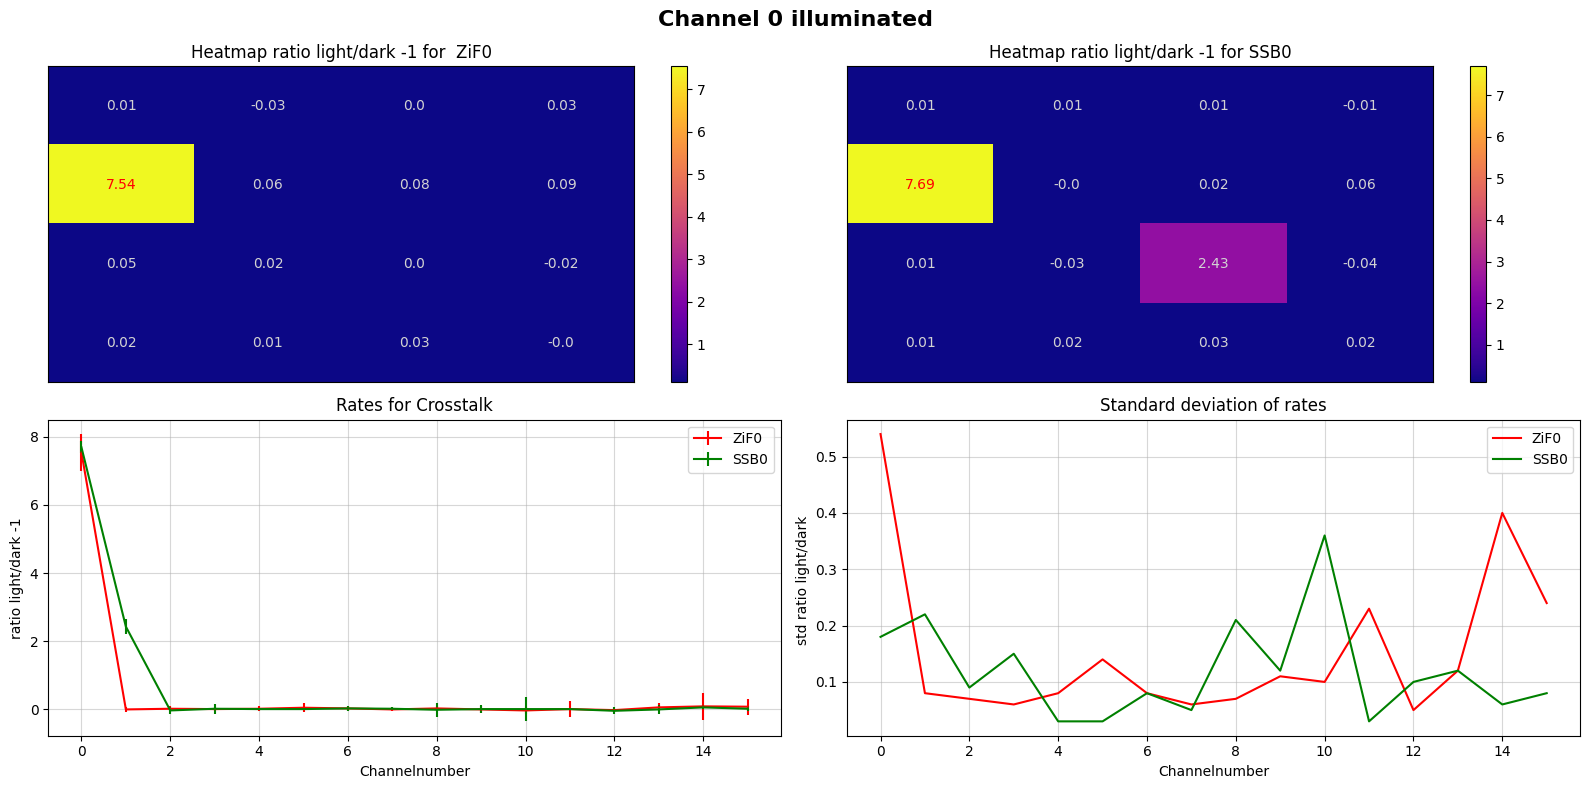

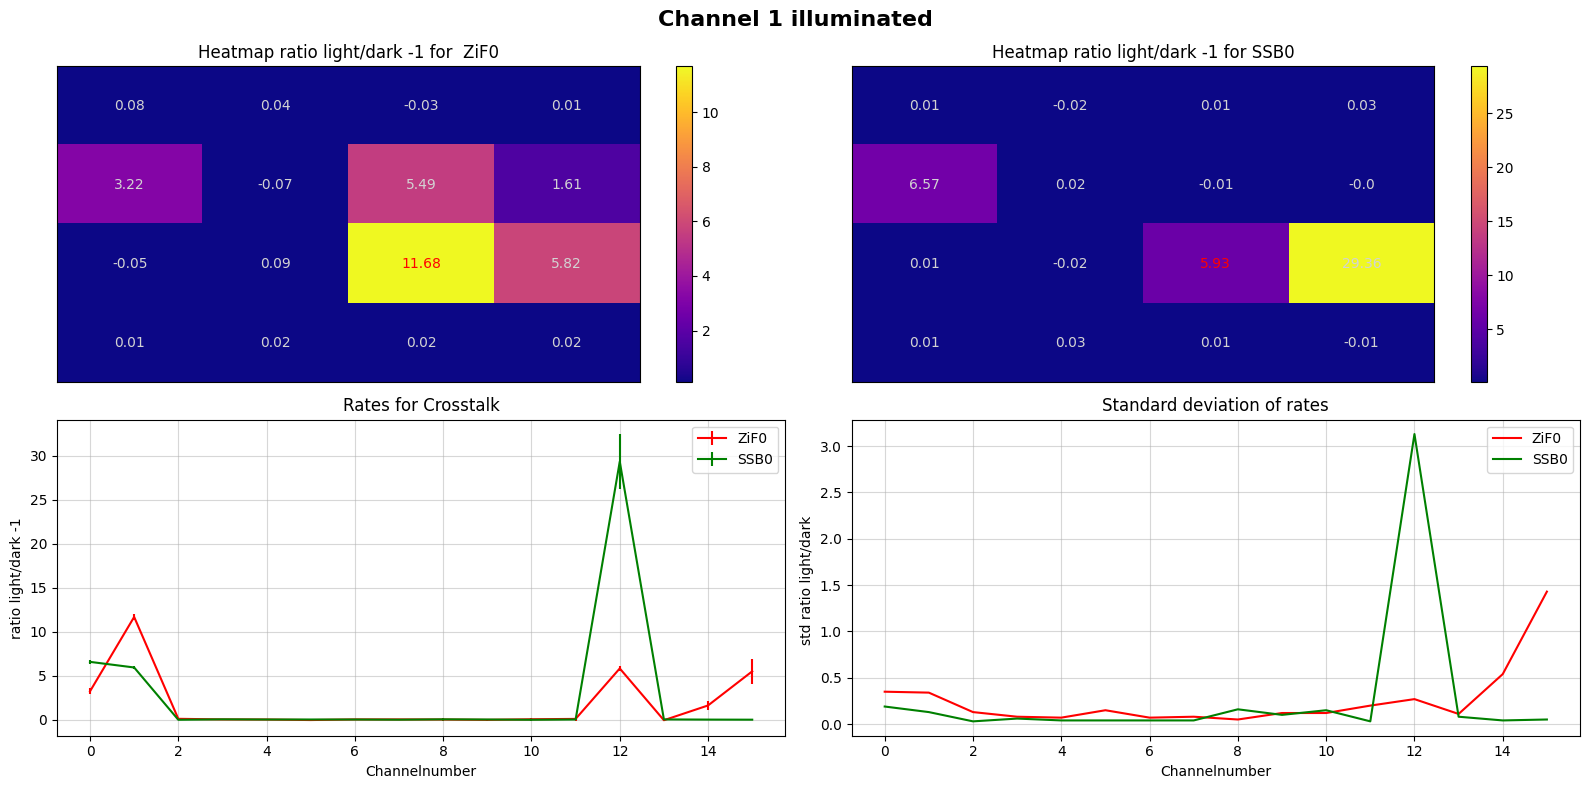

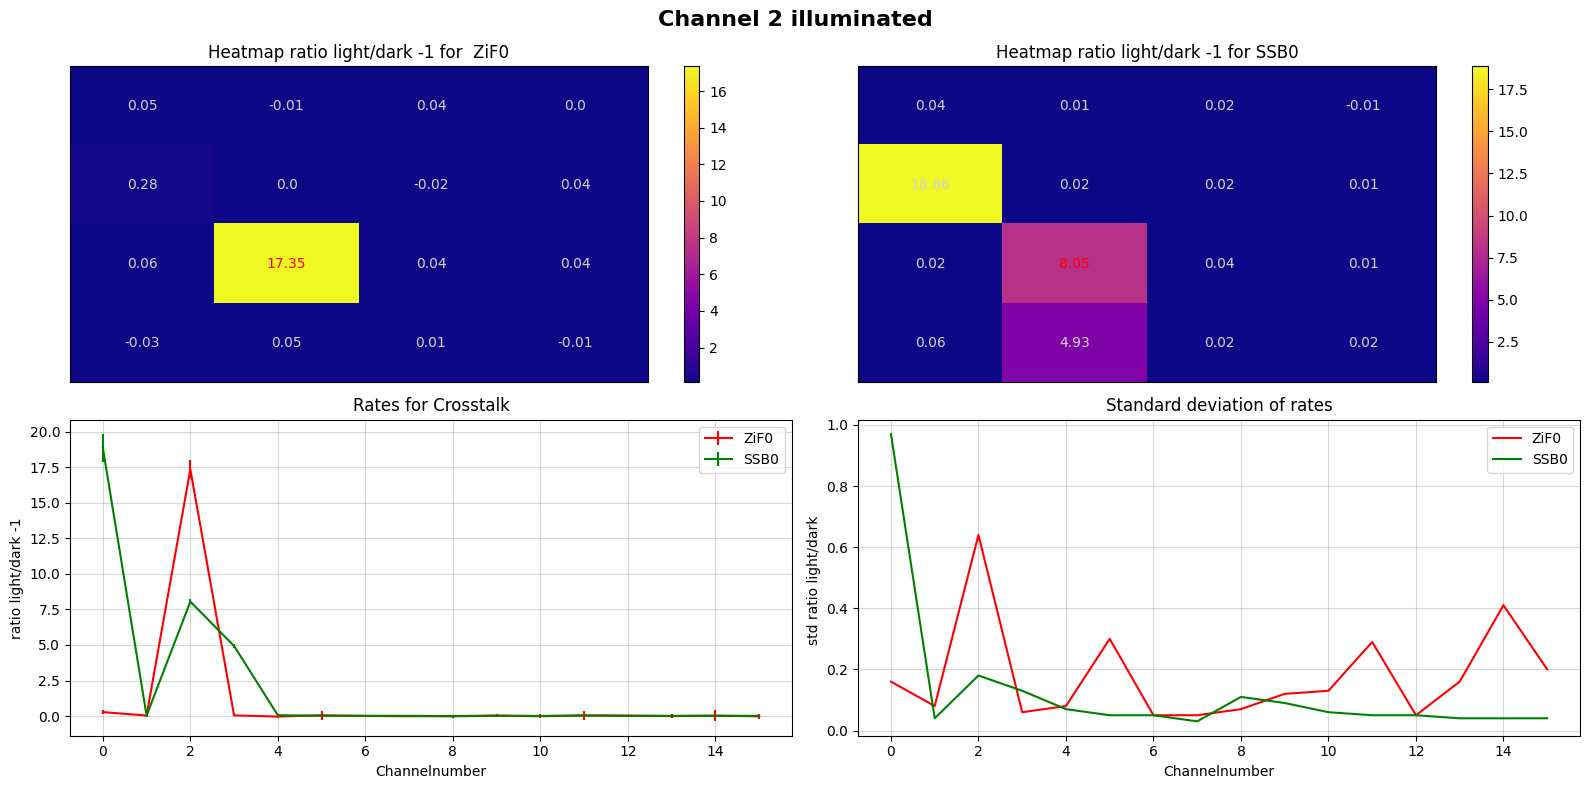

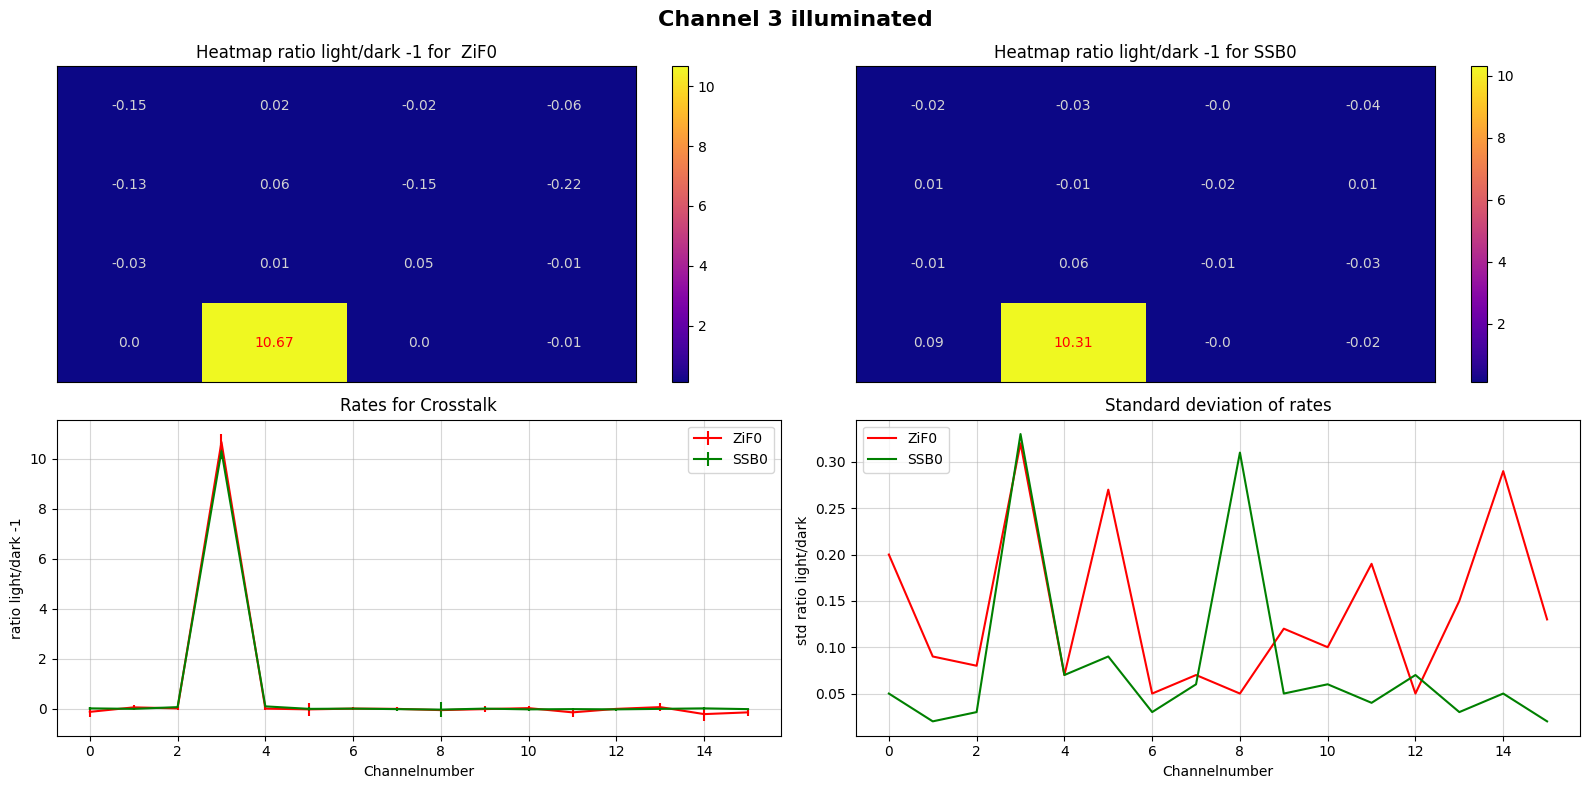

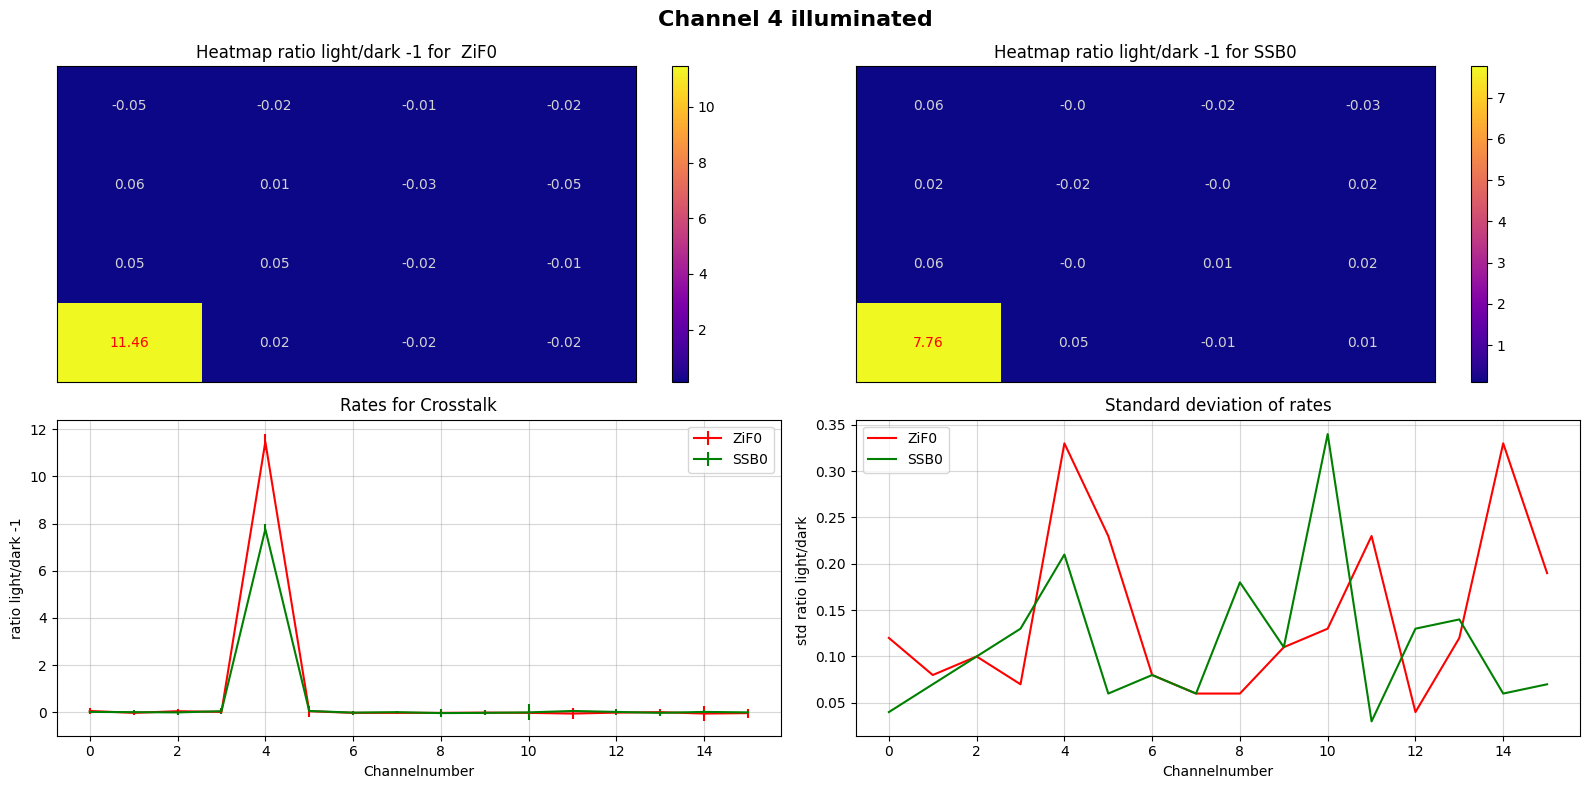

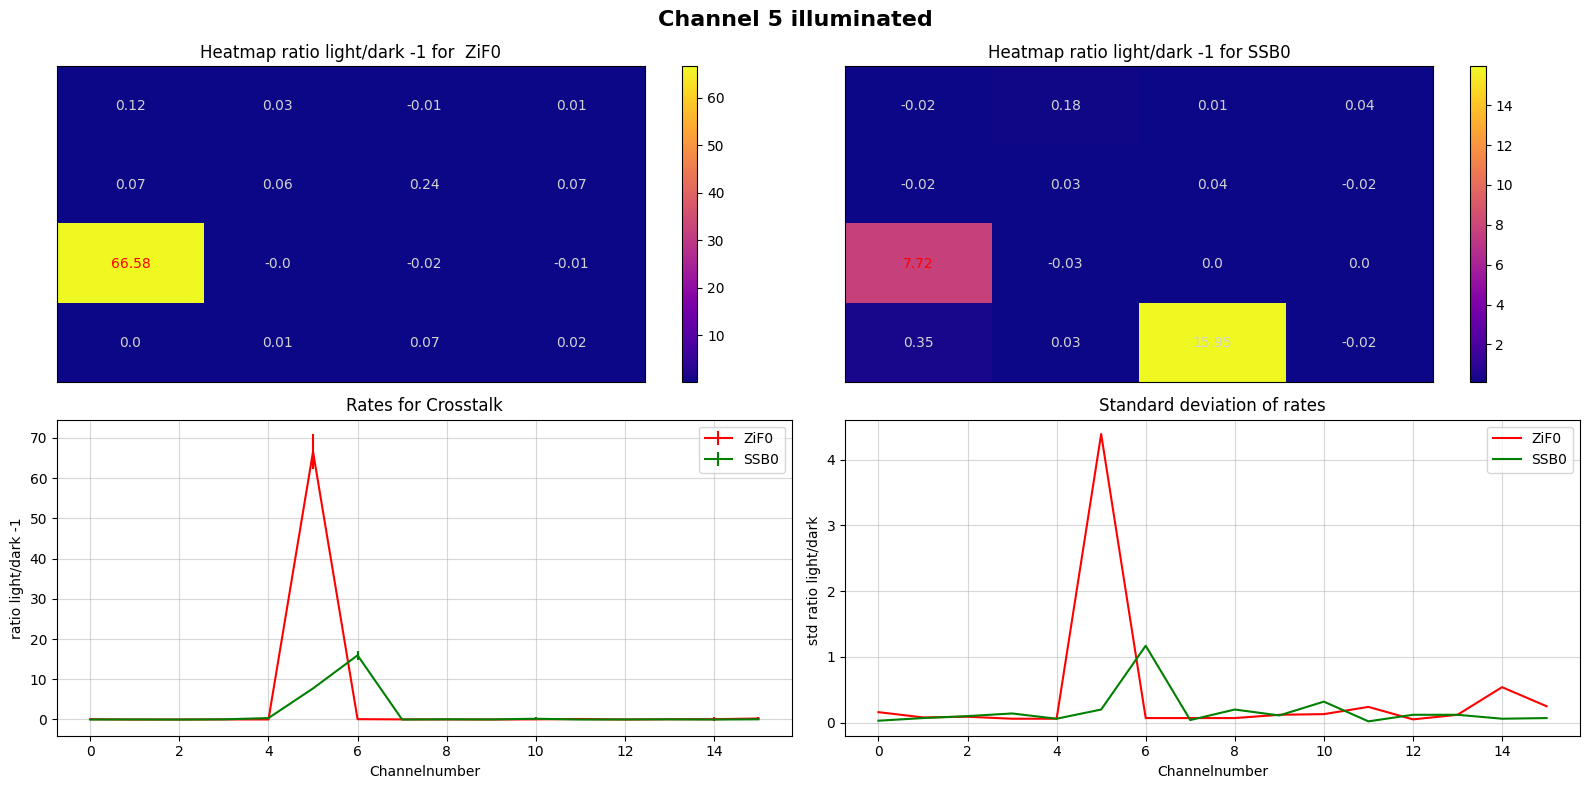

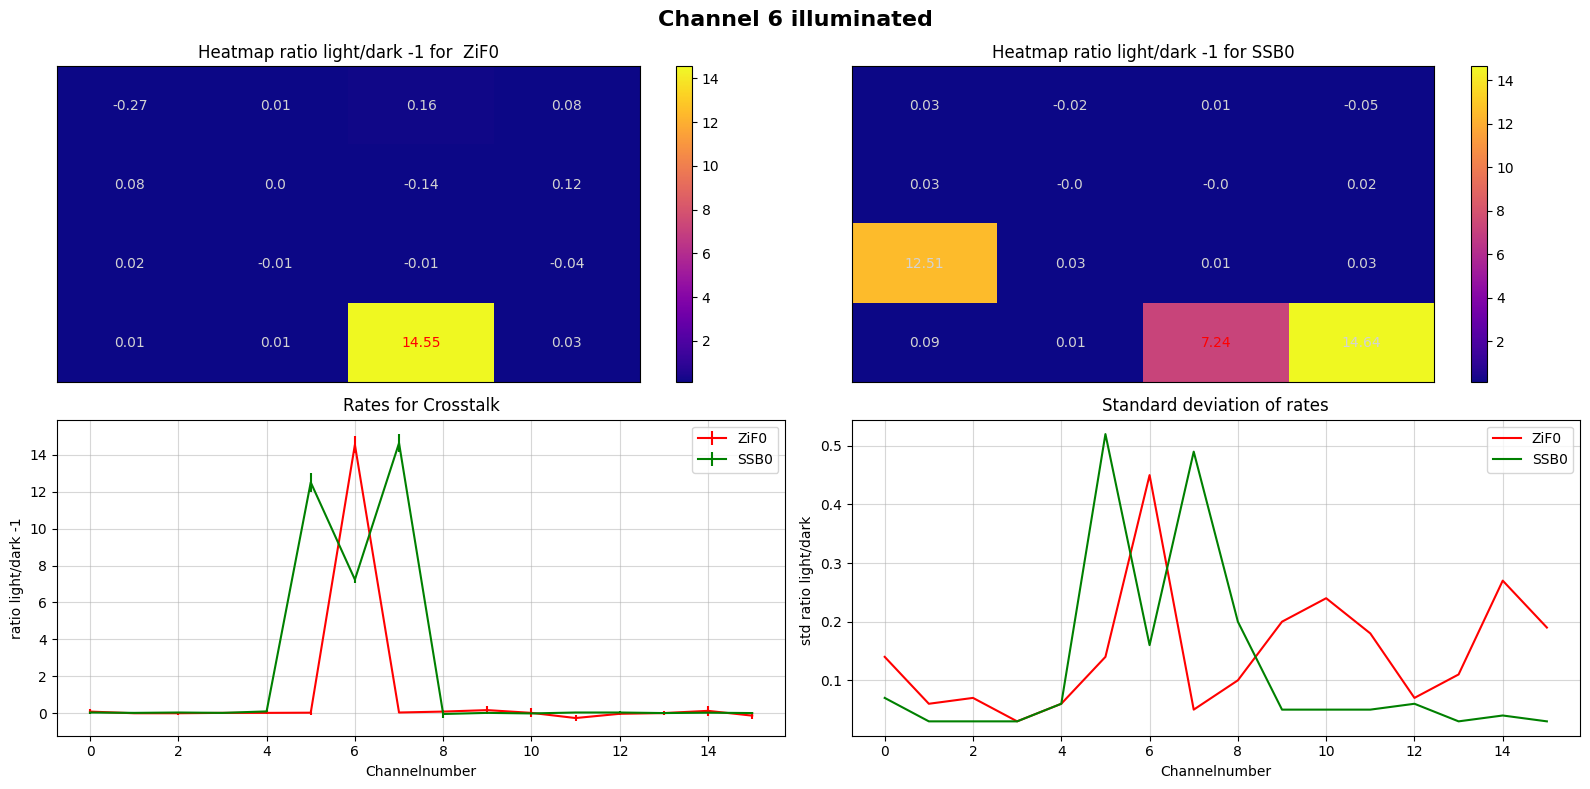

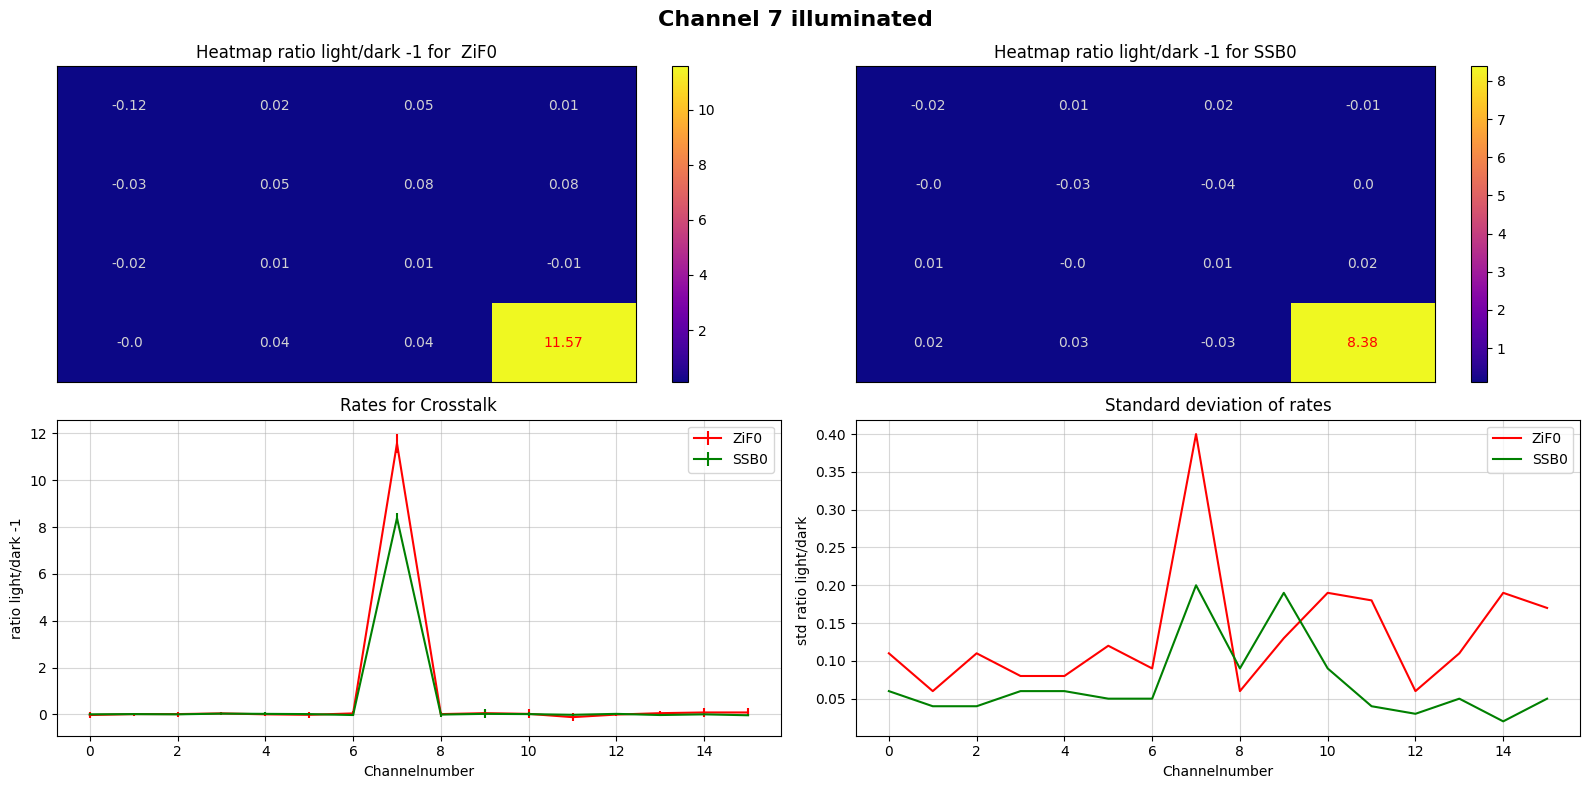

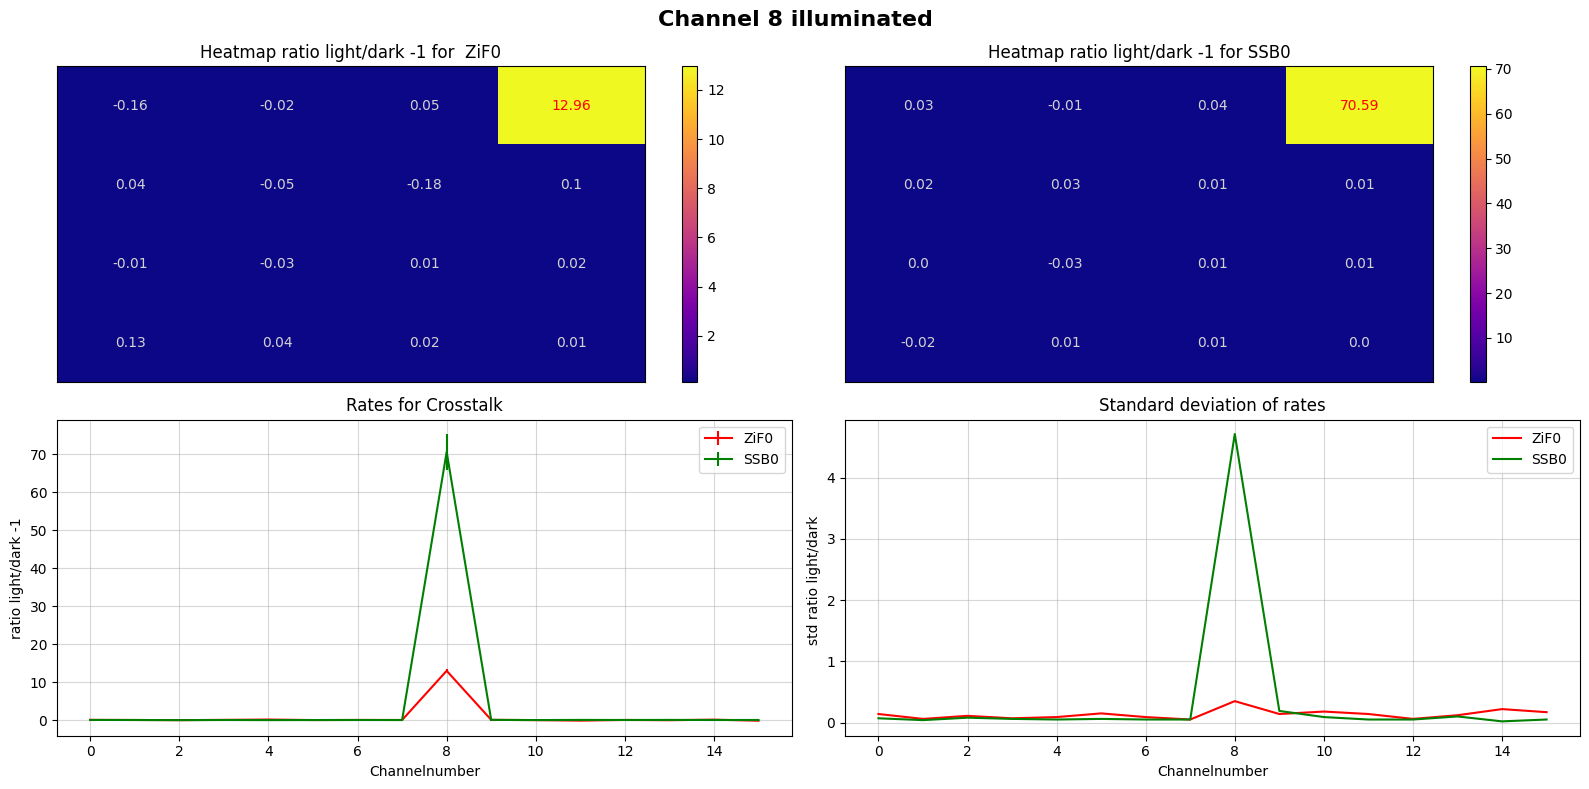

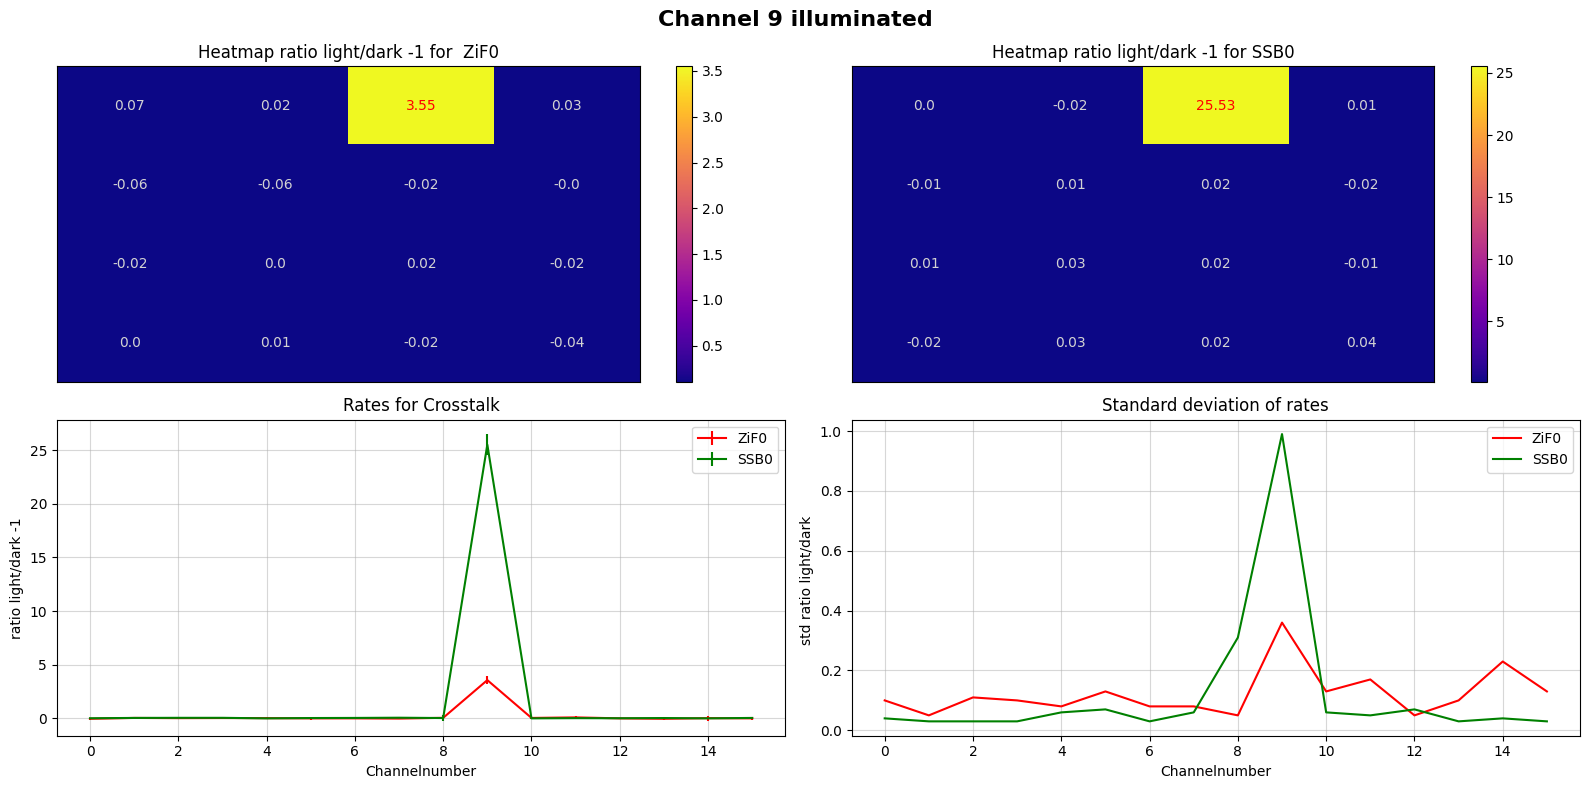

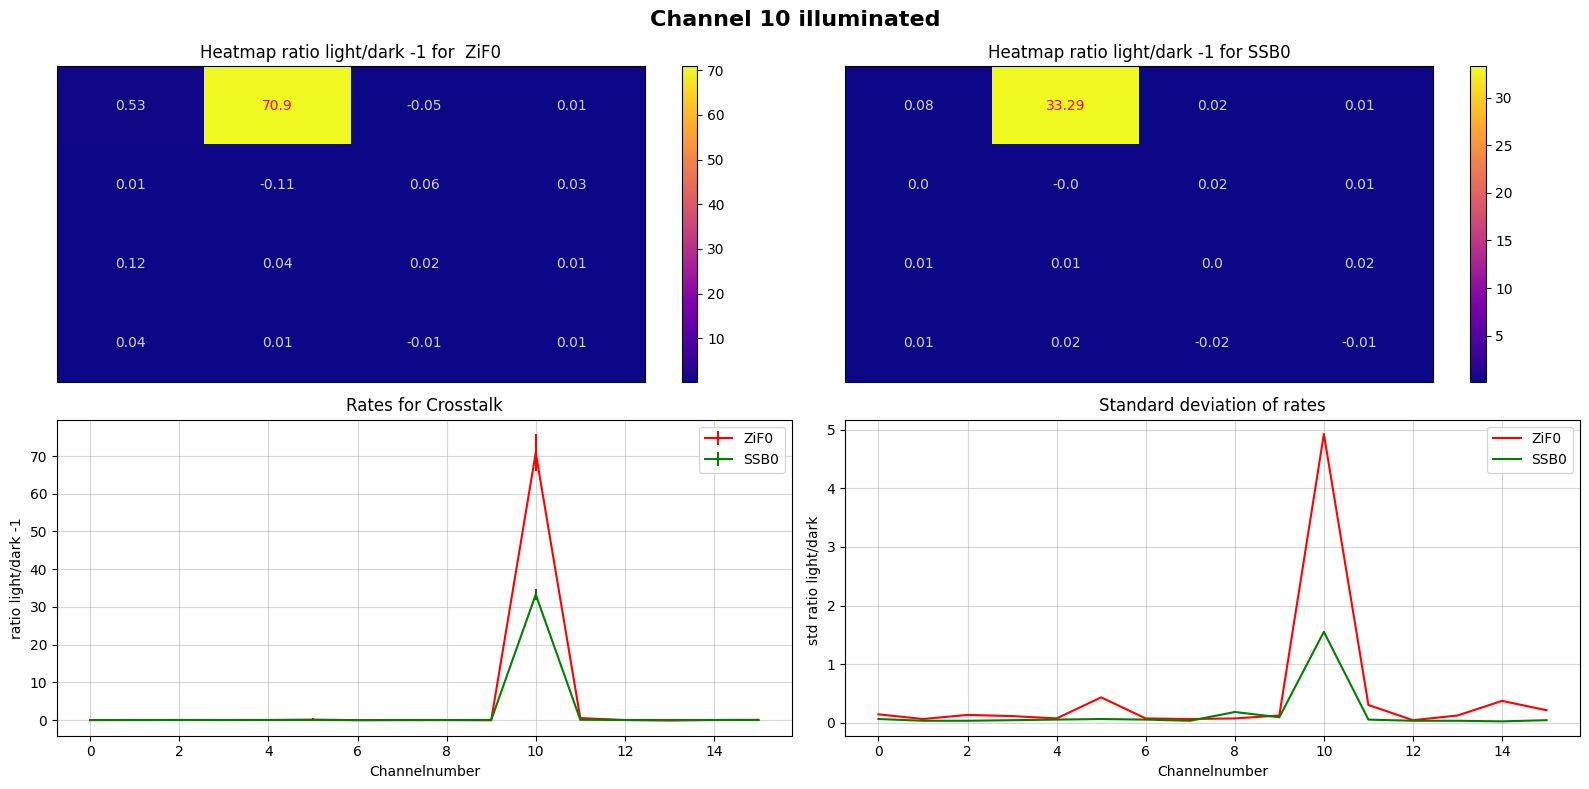

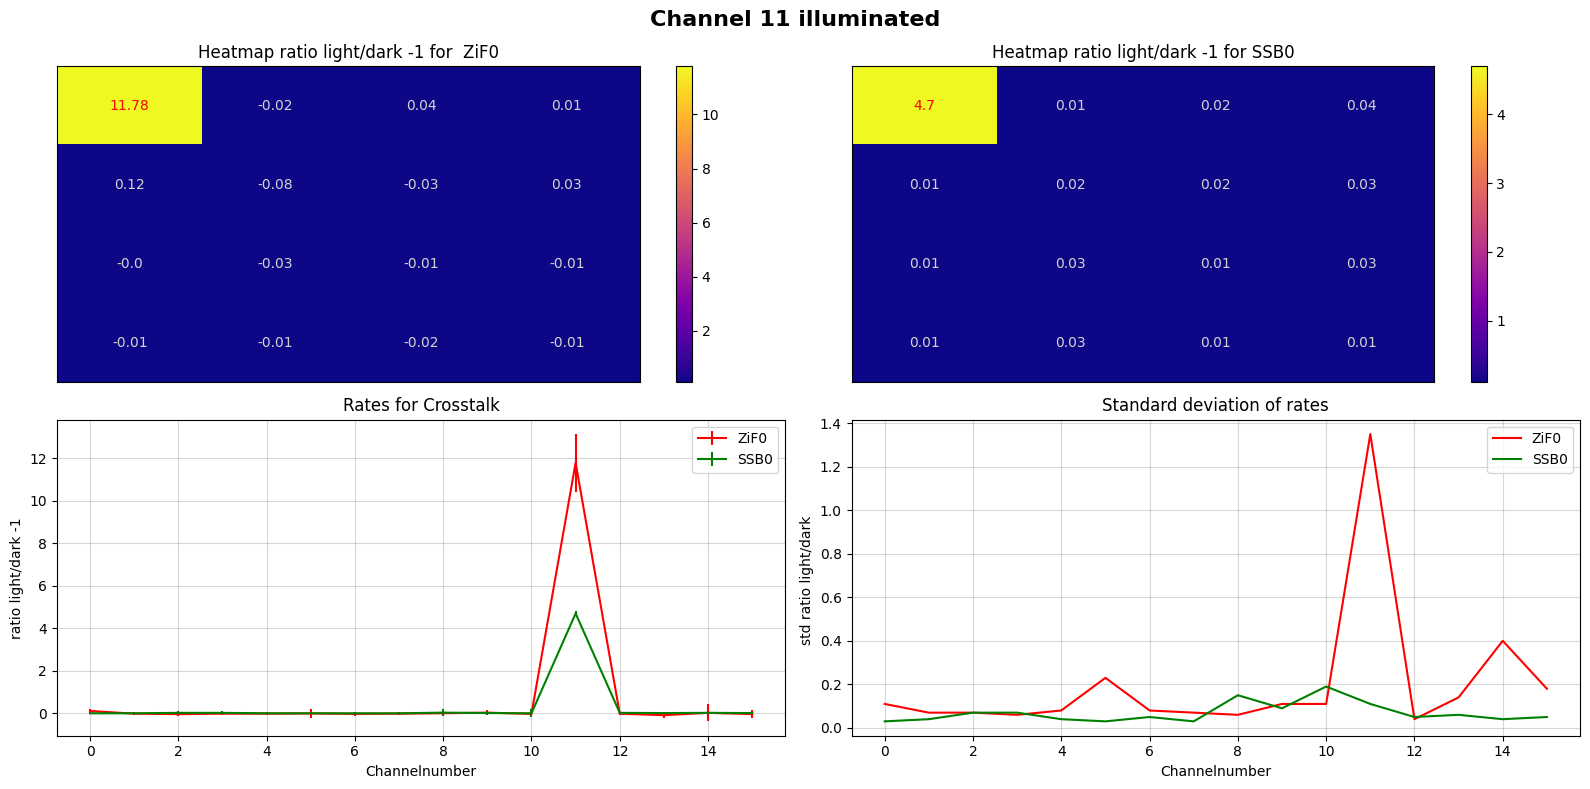

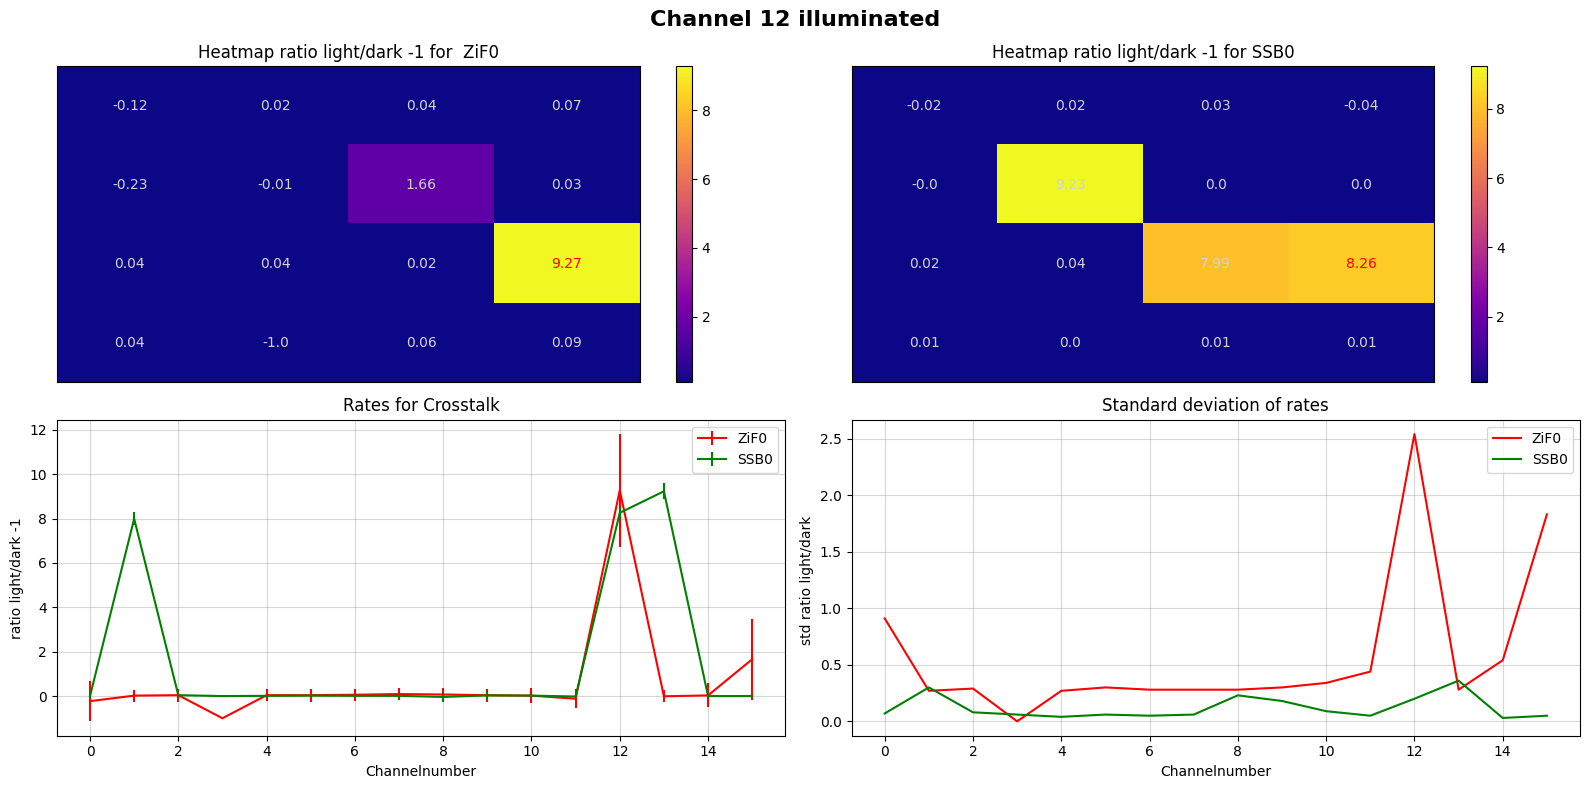

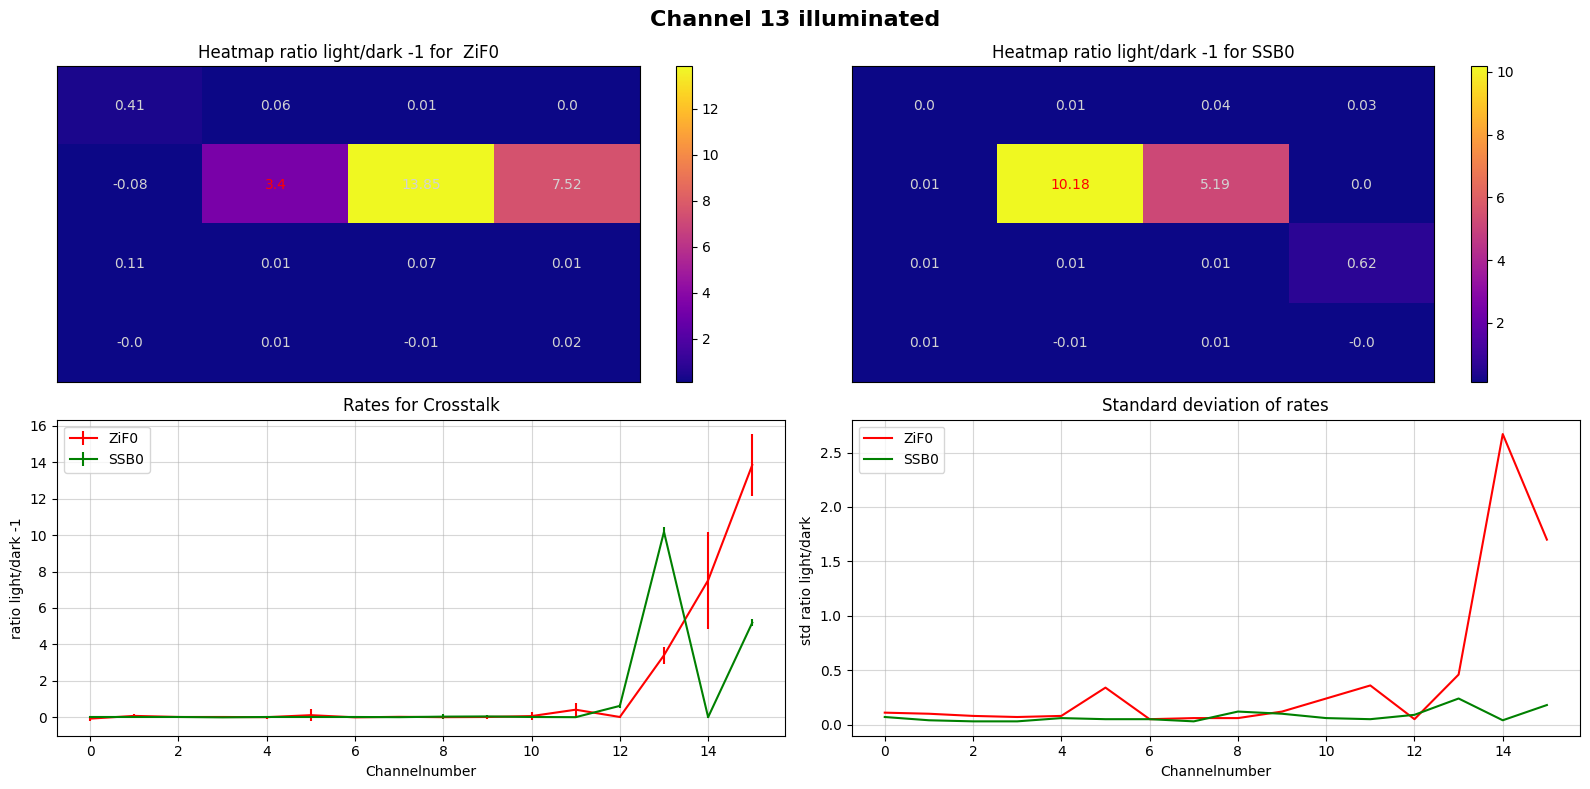

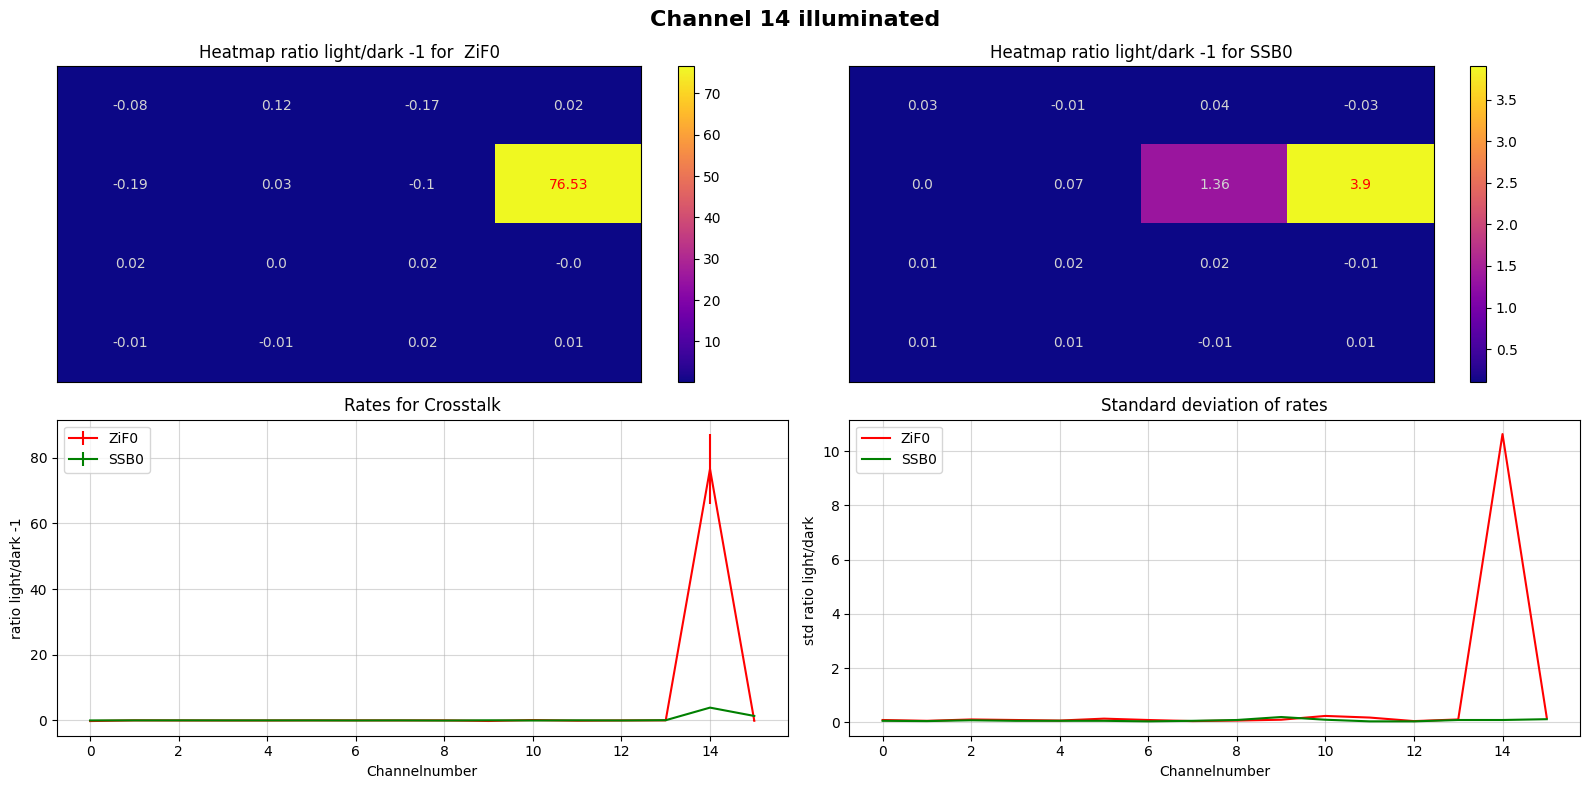

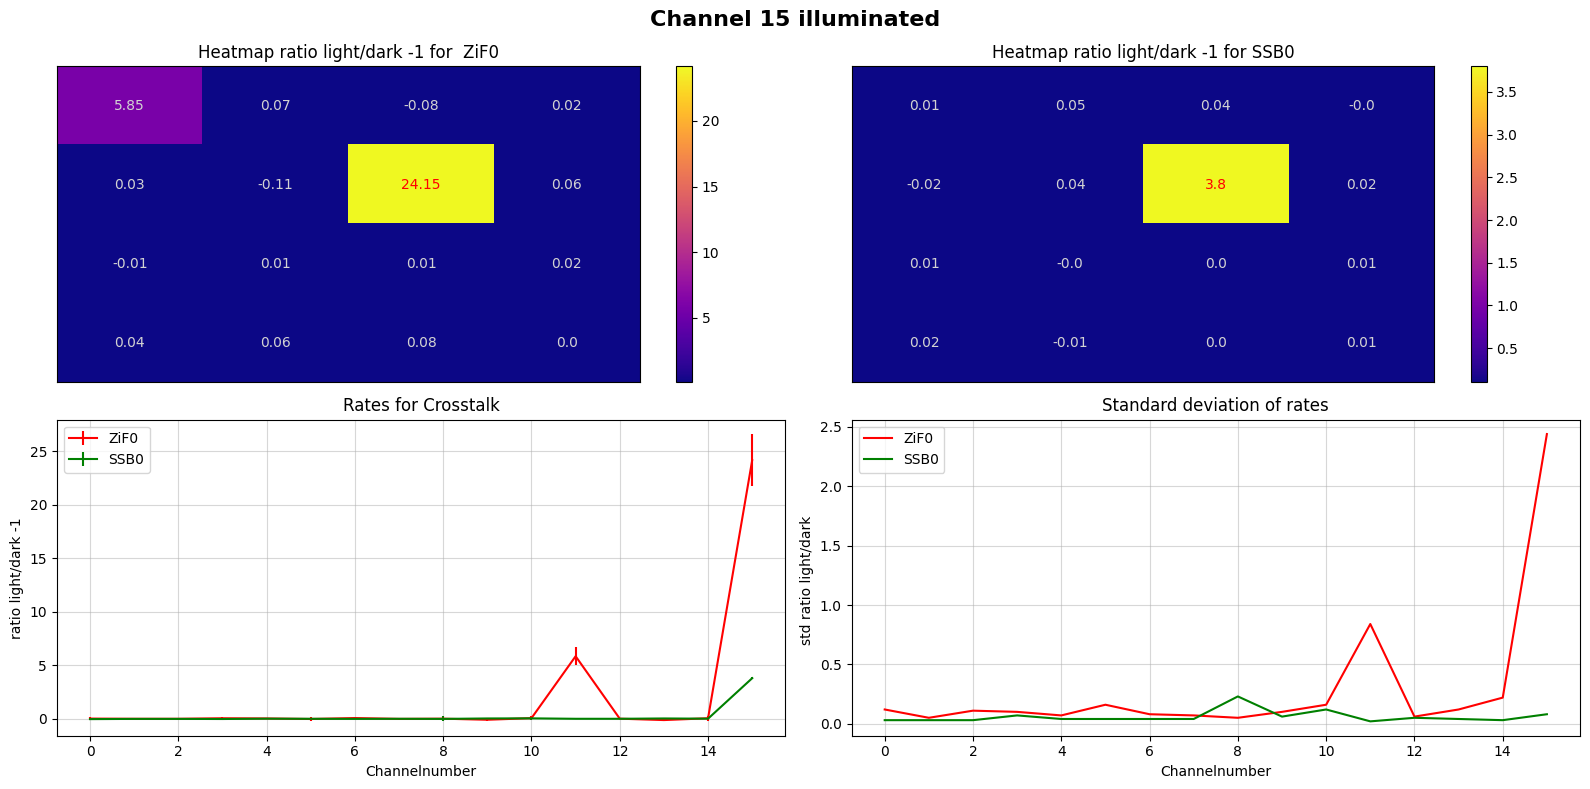

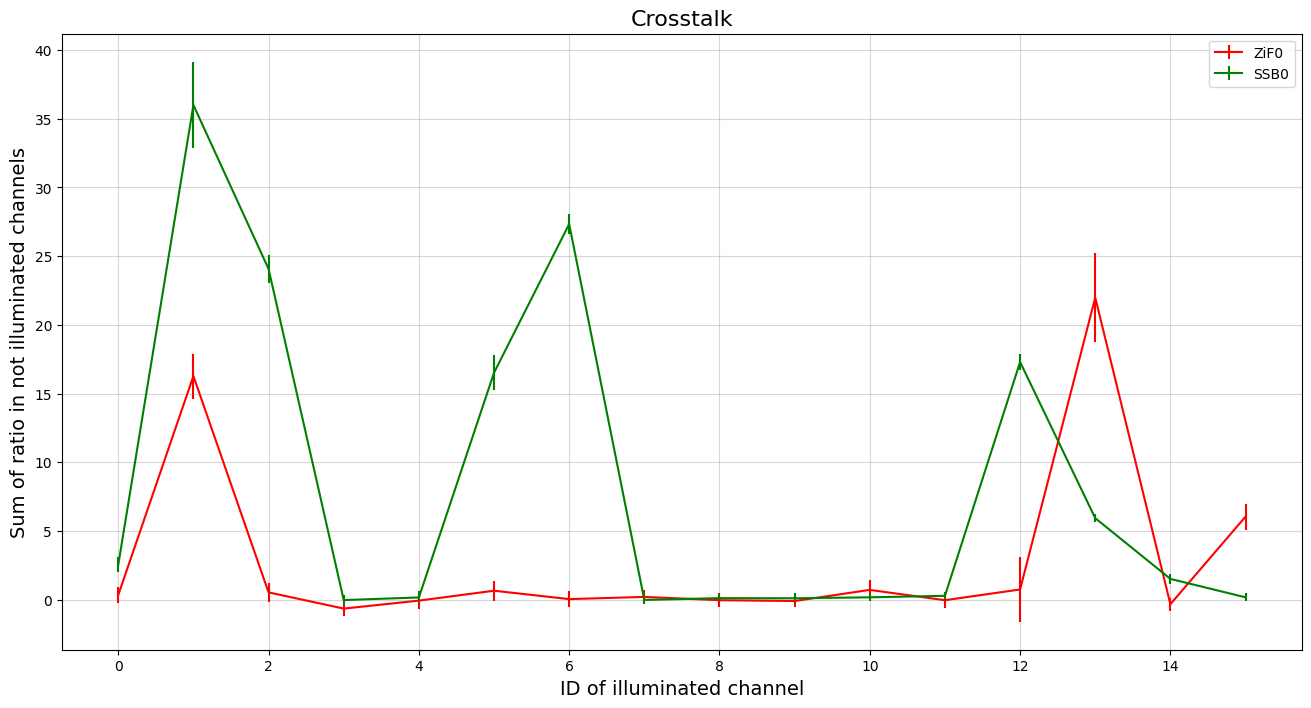

In [2]:
import numpy as np
import matplotlib
import matplotlib as mpl
import json
import matplotlib.pyplot as plt
import os

layout = np.array([['11', '10', '09', '08'],
                        ['00', '13', '15', '14'],
                        ['05', '02', '01', '12'],
                        ['04', '03', '06', '07']])

def heatmap(data_light, data_dark, ch):
    # Convert single channel to list for uniform handling
    channels = [ch] if isinstance(ch, int) else ch

    pe_two = np.array([[26, 100, 161, 108],
                        [89, 117, 37, 40],
                        [37, 41, 46, 48],
                        [105, 49, 38, 101]]) 

    offset = np.array([[0, 1, 2, 1],
                        [1, 1, 0, 0],
                        [0, 0, 0, 0],
                        [1, 0, 0, 1]]) 

    problem = []

    ratio_map = []
    for k in range(4):
        rates= []
        for l in range(4):
            for channel in channels:
                if layout[k,l] != str(channel).zfill(2):
                    continue
                
                rates_light = np.array(data_light['rates'][channel])
                rates_dark = np.array(data_dark['rates'][channel])
                rates.append(np.round(rates_light / rates_dark -1, 2))

        ratio_map.append(rates)

    ratio = ratio_map
    #print(ratio)
    return ratio

def plot_rates(data_light, data_dark, ch):
    channels = [ch] if isinstance(ch, int) else ch
    rates= []
    rates_error =[]
    for channel in channels:
        
        rates_light = np.array(data_light['rates'][channel])
        rates_dark = np.array(data_dark['rates'][channel])
        ratio = np.round(rates_light / rates_dark, 2)
        rates.append(ratio-1)

        rates_light_error = np.array(data_light['std'][channel])
        rates_dark_error = np.array(data_dark['std'][channel])
        error = ratio * np.sqrt((rates_light_error/rates_light)**2 + (rates_dark_error/rates_dark)**2)

        rates_error.append(np.round(error, 2))               

    #print(ratio)
    return rates, rates_error

channels = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]

result = []
cross1 = []
cross1_error = []
cross2 = []
cross2_error = []
for a in range(16):


    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(16, 8))
    number = str(a).zfill(2)
    with open(f'scans/crosstalk/24.04/SSB0_ch{a}_dark.json', 'r') as f_dark, open(f'scans/crosstalk/24.04/SSB0_ch{a}.json', 'r') as f_light:
        data_dark = json.load(f_dark)
        data_light = json.load(f_light)
        ratio_cap = heatmap(data_light, data_dark, channels)
        ratio, ratio_error = plot_rates(data_light, data_dark, channels)
        dark_rates = np.delete(ratio, a)
        dark_rates_error = np.delete(ratio_error, a)        
        cross1.append(np.sum(dark_rates))
        cross1_error.append(np.sqrt(np.sum(dark_rates_error**2)))


    if np.max(ratio_cap) > 1000:
        norm1 = 'log'
    else:
        norm1 = 'linear'
    im1 = ax1.imshow(ratio_cap, cmap='plasma', aspect='auto', norm= norm1, vmin=0.1)
    ticks =[]
    ax1.set_xticks(ticks)
    ax1.set_yticks(ticks)

    for i in range(4):
        for j in range(4):
            if layout[i,j] == str(int(number)).zfill(2):
                text = ax1.text(j, i, ratio_cap[i][j], ha="center", va="center", color="r")
            else:
                text = ax1.text(j, i, ratio_cap[i][j], ha="center", va="center", color="lightgrey")
    ax1.set_title(f"Heatmap ratio light/dark -1 for  ZiF0")
    plt.colorbar(im1, ax=ax1)

    ax4.plot(range(16), ratio_error, color= 'r', label='ZiF0')
    ax3.errorbar(range(16), ratio, yerr=ratio_error, color= 'r', label='ZiF0')


    with open(f'scans/Mutrig4/SSB0_ch{a}_dark.json', 'r') as f_dark, open(f'scans/Mutrig4/SSB0_ch{a}.json', 'r') as f_light:
        data_dark = json.load(f_dark)
        data_light = json.load(f_light)
        ratio_mask = heatmap(data_light, data_dark, channels)
        ratio, ratio_error = plot_rates(data_light, data_dark, channels)
        dark_rates = np.delete(ratio, a)
        dark_rates_error = np.delete(ratio_error, a)        
        cross2.append(np.sum(dark_rates))
        cross2_error.append(np.sqrt(np.sum(dark_rates_error**2)))

    if np.max(ratio_mask)>1000:
        norm2 = 'log'
    else:
        norm2 = 'linear'
    im2 = ax2.imshow(ratio_mask, cmap='plasma', aspect='auto', norm= norm2, vmin=0.1)
    ticks =[]
    ax2.set_xticks(ticks)
    ax2.set_yticks(ticks)

    for i in range(4):
        for j in range(4):
            if layout[i,j] == str(int(number)).zfill(2):
                text = ax2.text(j, i, ratio_mask[i][j], ha="center", va="center", color="r")
            else:
                text = ax2.text(j, i, ratio_mask[i][j], ha="center", va="center", color="lightgrey")
    ax2.set_title(f"Heatmap ratio light/dark -1 for SSB0")
    plt.colorbar(im2, ax=ax2)


    ax3.errorbar(range(16), ratio, yerr=ratio_error, color= 'g', label='SSB0')
    ax4.plot(range(16), ratio_error, color= 'g', label='SSB0')

    ax3.set_xlabel('Channelnumber')
    ax3.set_ylabel('ratio light/dark -1')
    ax3.set_title(f'Rates for Crosstalk')
    ax3.legend()
    ax3.grid(True, alpha=0.5)
    ax4.set_xlabel('Channelnumber')
    ax4.set_ylabel('std ratio light/dark ')
    ax4.set_title(f'Standard deviation of rates')
    ax4.legend()
    ax4.grid(True, alpha=0.5)
    #plt.yscale('log')

    fig.suptitle(f'Channel {a} illuminated',fontsize=16, fontweight='bold')
    fig.tight_layout()
    plt.show()                     

plt.figure(figsize=(16,8))
plt.errorbar(range(16), cross1, yerr=cross1_error, color= 'r', label='ZiF0')
plt.errorbar(range(16), cross2, yerr=cross2_error, color= 'g', label='SSB0')
plt.xlabel('ID of illuminated channel', fontsize=14)
plt.ylabel('Sum of ratio in not illuminated channels', fontsize=14)
plt.title('Crosstalk', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

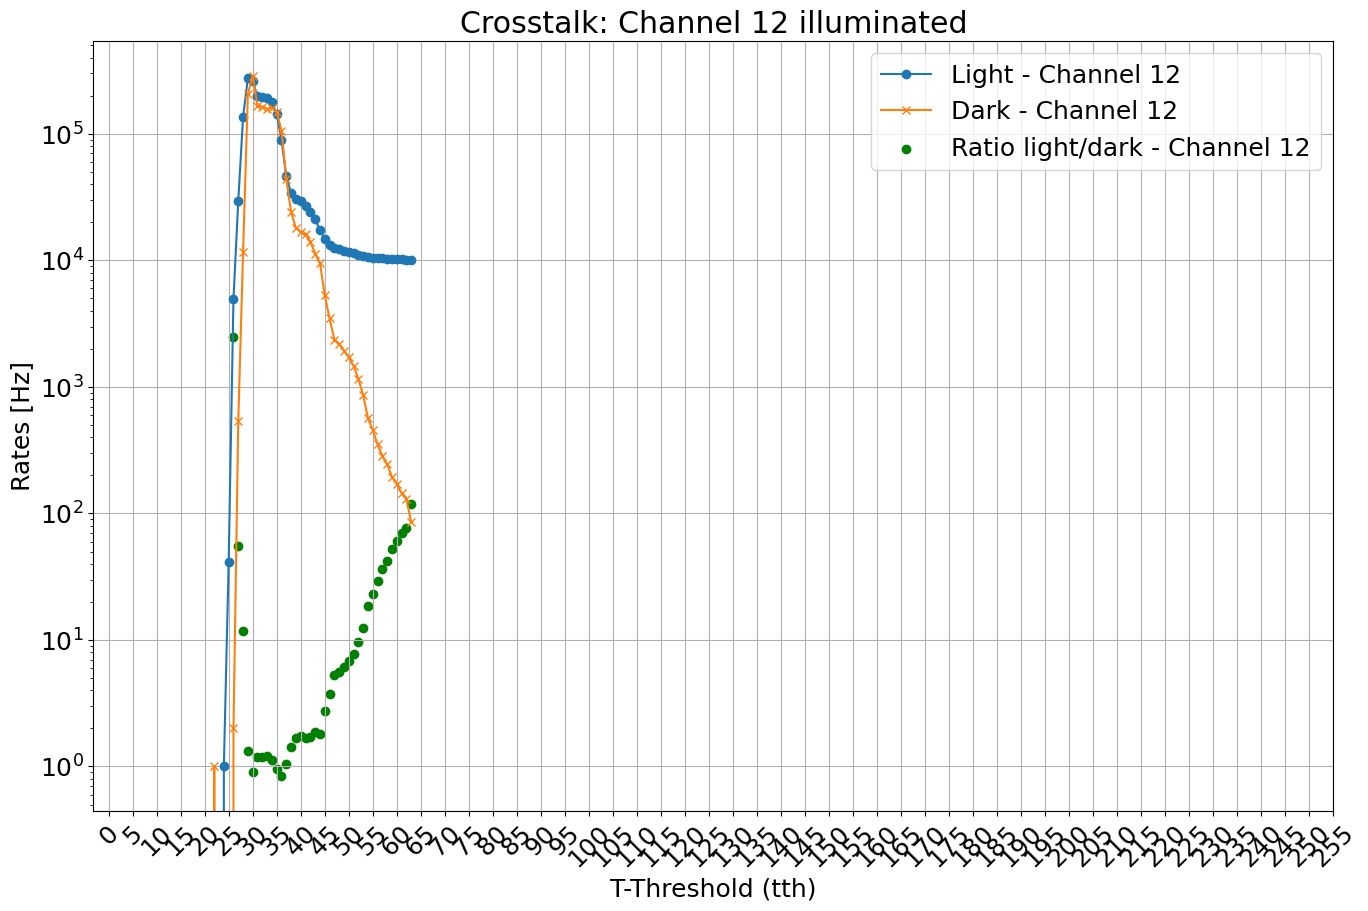

In [21]:
import json
import matplotlib.pyplot as plt
import numpy as np
import math

def plot_threshold_scan(data_light, data_dark, ch, ref):
    # Convert single channel to list for uniform handling
    channels = [ch] if isinstance(ch, int) else ch
    
    plt.figure(figsize=(16, 10))
    plt.rcParams.update({'font.size': 18})

    for channel in channels:
        rates= []
        factor = []
        ratio_tth = []
        rates_light = np.array(data_light['rates'][channel])
        rates_dark = np.array(data_dark['rates'][channel])
        for i in np.arange(0, 64, 1):
            if not np.isnan(rates_light[i]) and not np.isnan(rates_dark[i]) and rates_dark[i]>0 and rates_light[i]>0:
                rates.append(rates_light[i] / rates_dark[i])
            else:
                rates.append(0)
        tth = np.array(data_light['th'][channel])
        for i in np.arange(0, 64, 1):  
            ratio_tth.append(tth[i])
        plt.plot(tth, rates_light, label=f'Light - Channel {channel}', marker='o')
        plt.plot(tth, rates_dark, label=f'Dark - Channel {channel}', marker='x')
        
        plt.scatter(ratio_tth, rates, label=f'Ratio light/dark - Channel {channel}', marker='o', color='g')

        for rate in rates:
            if not np.isnan(rate) and rate !=0 and np.isfinite(rate):
                factor.append(rate)
        #print(f'Channel {channel}:' ,np.mean(factor))
    plt.title(f'Crosstalk: Channel {ref} illuminated')
    plt.xlabel('T-Threshold (tth)')
    plt.ylabel('Rates [Hz]')
    plt.legend()
    
    #plt.vlines(ref, 0, 10**6, color='k')
    plt.xticks(np.arange(0, 256, 5), rotation=45)
    #plt.xlim(120, 191)
    #plt.xlim(0, 128)
    #plt.ylim(-1, 2)
    plt.yscale('log')
    plt.grid(True)
    plt.show()
    
channels = [12]   # [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
illum = '12'
with open(f'scans/crosstalk/20.04/SSB0_ch{illum}_dark.json', 'r') as f_dark, open(f'scans/crosstalk/20.04/SSB0_ch{illum}.json', 'r') as f_light:
    data_dark = json.load(f_dark)
    data_light = json.load(f_light)
    plot_threshold_scan(data_light, data_dark, channels, illum)

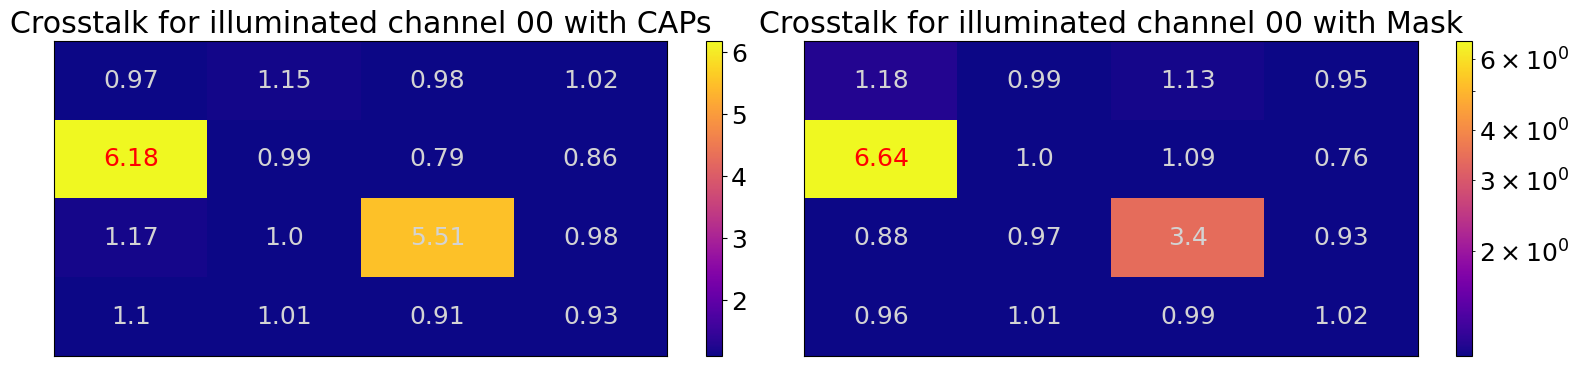

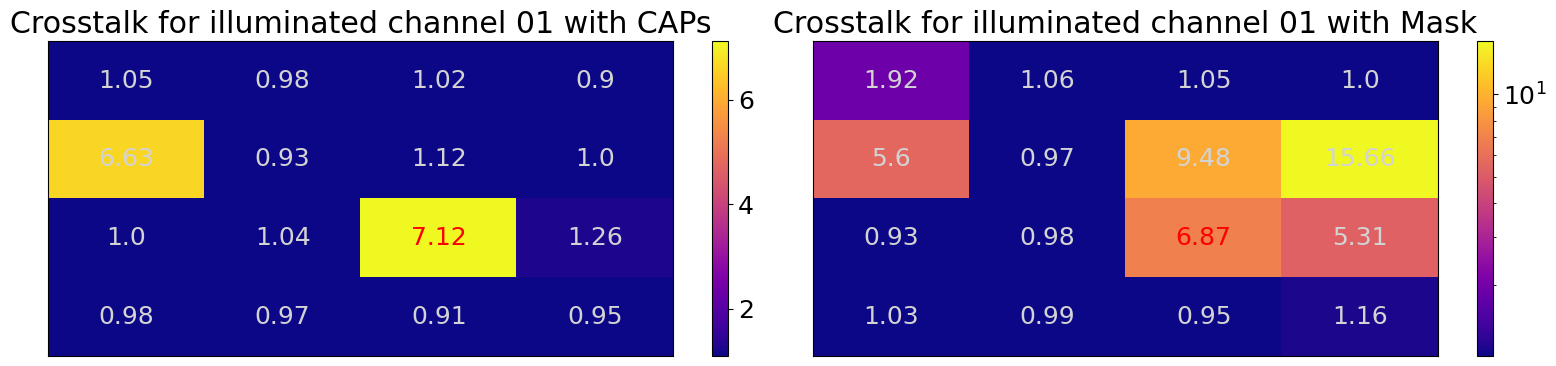

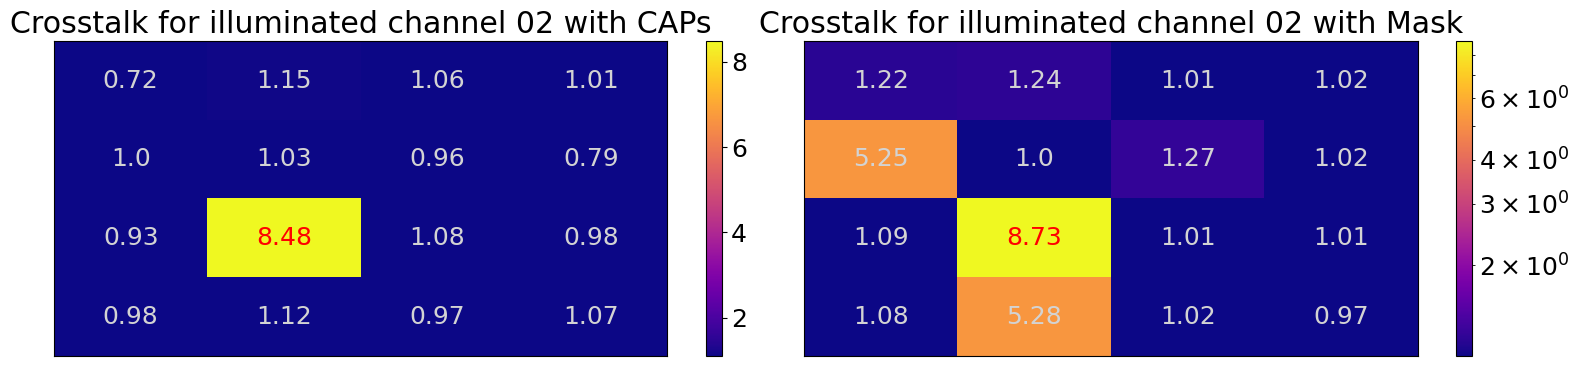

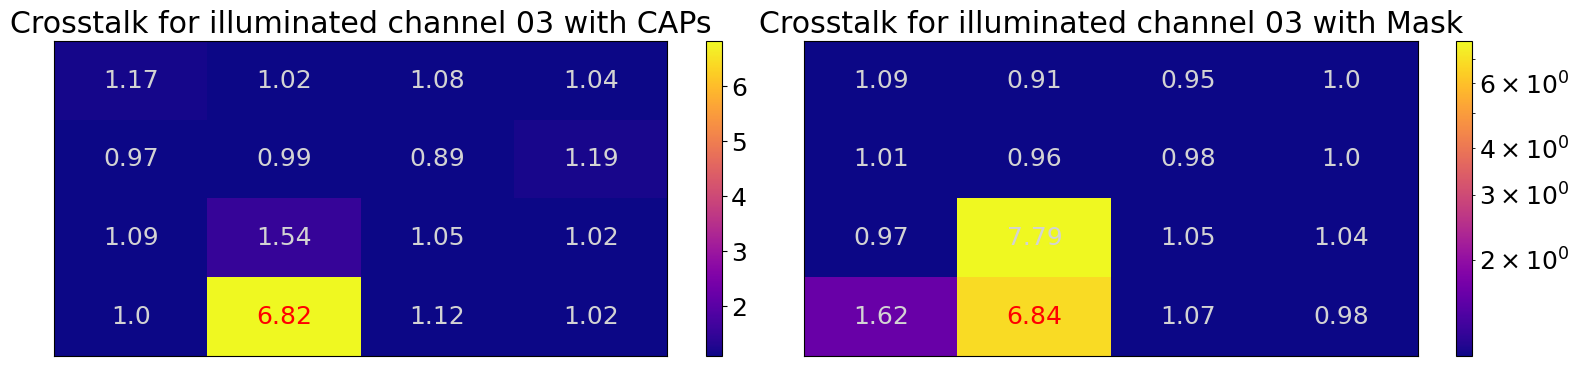

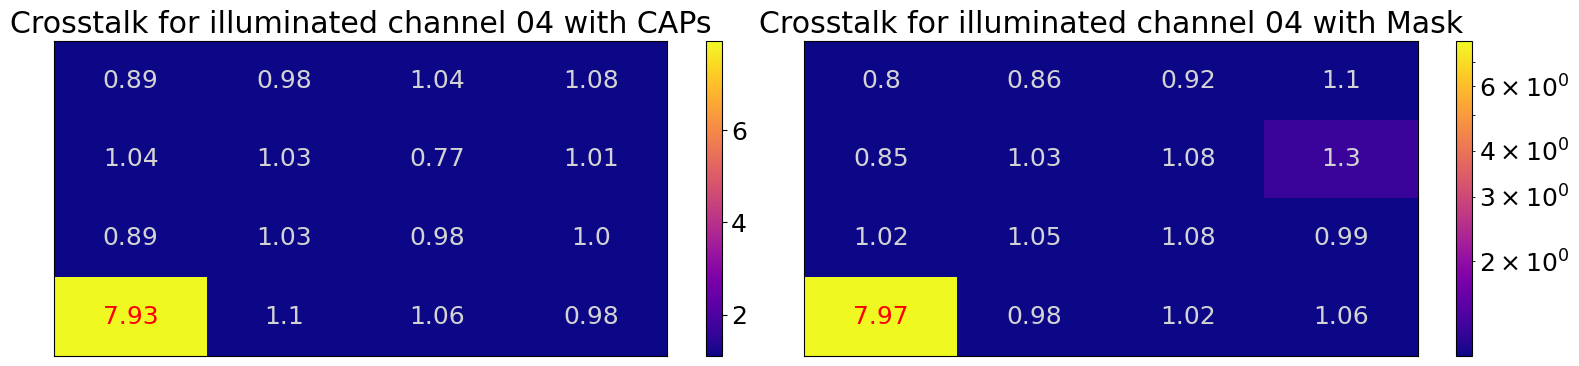

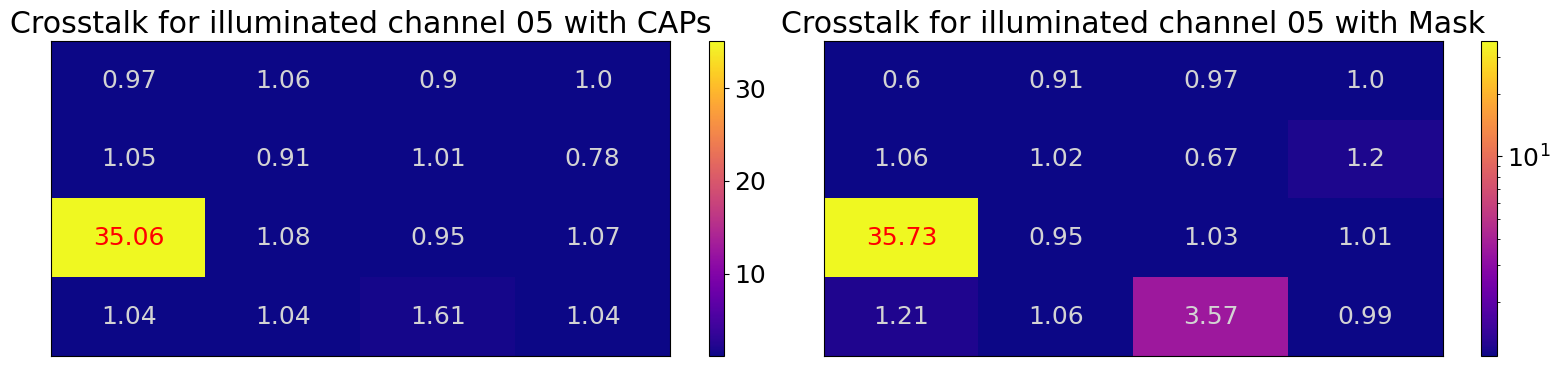

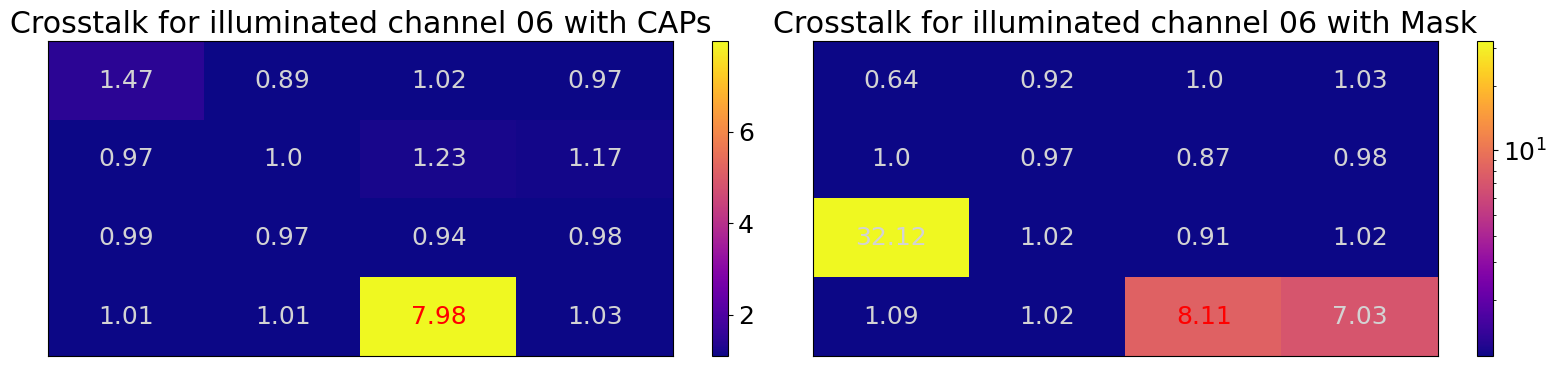

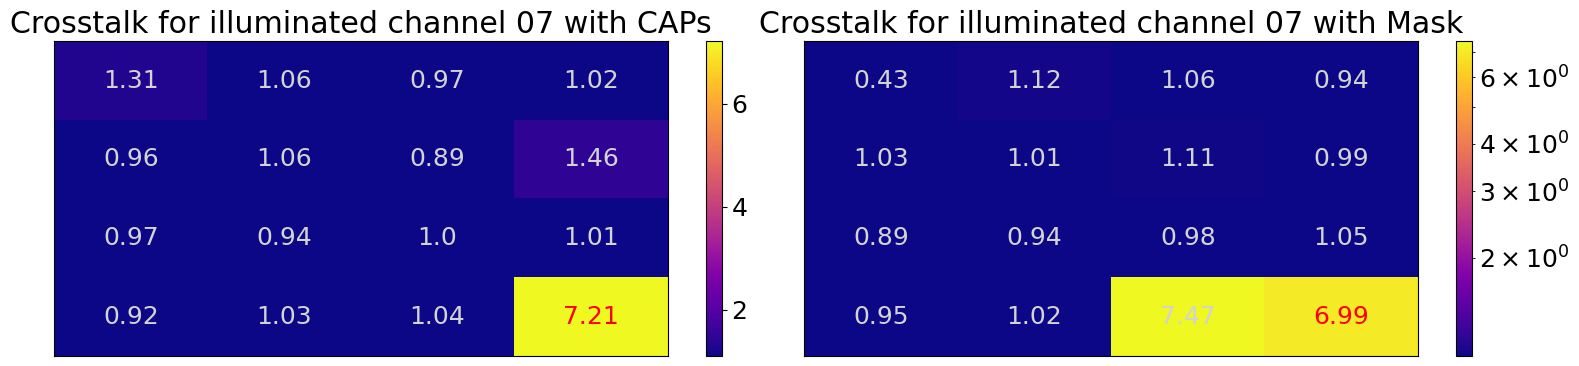

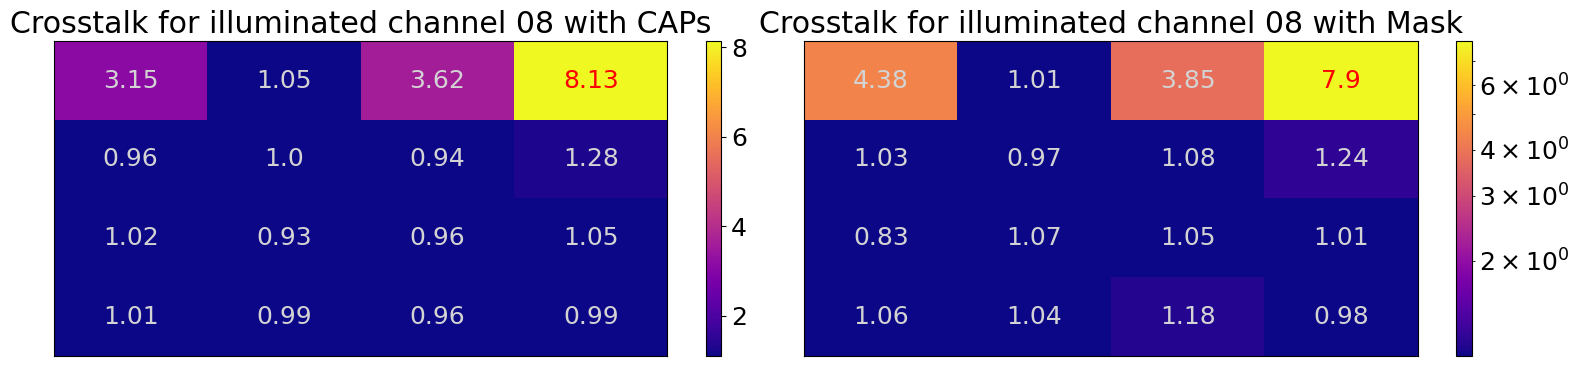

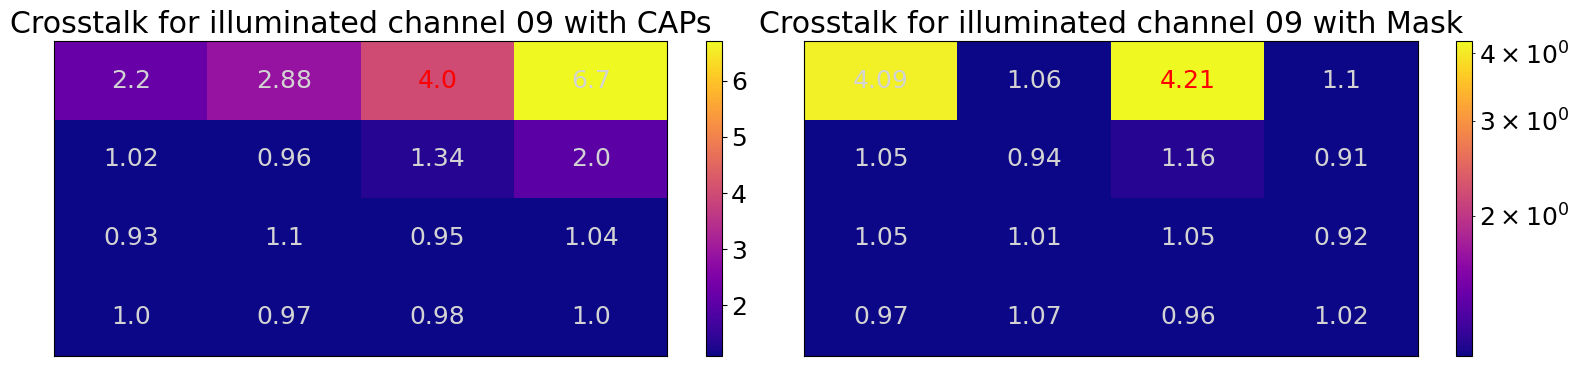

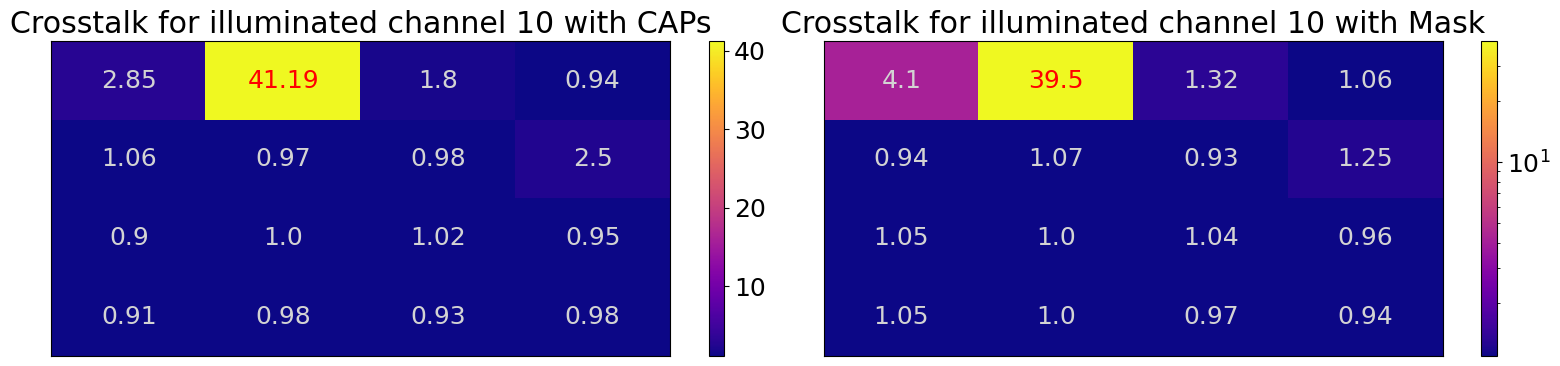

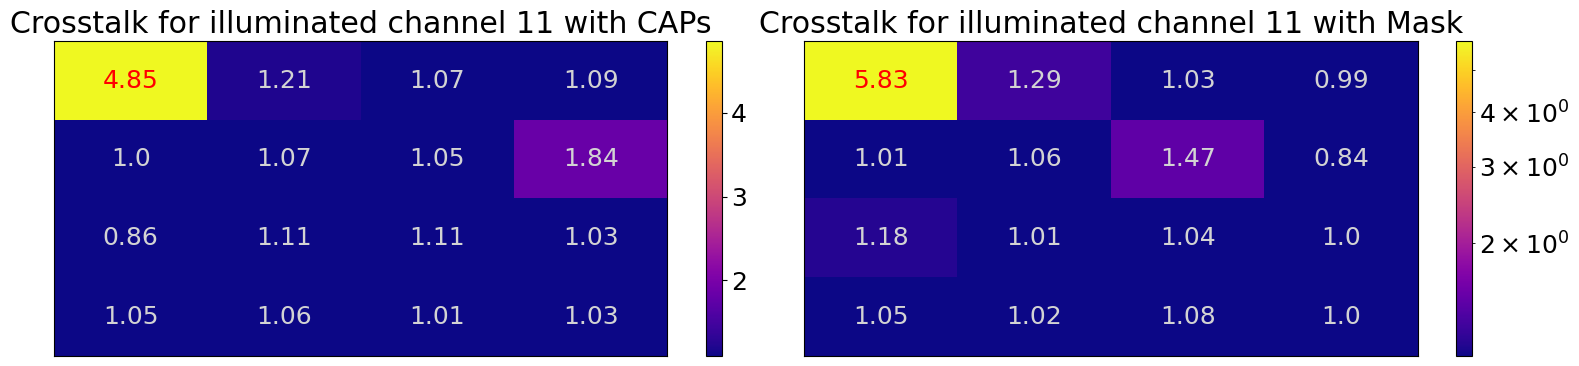

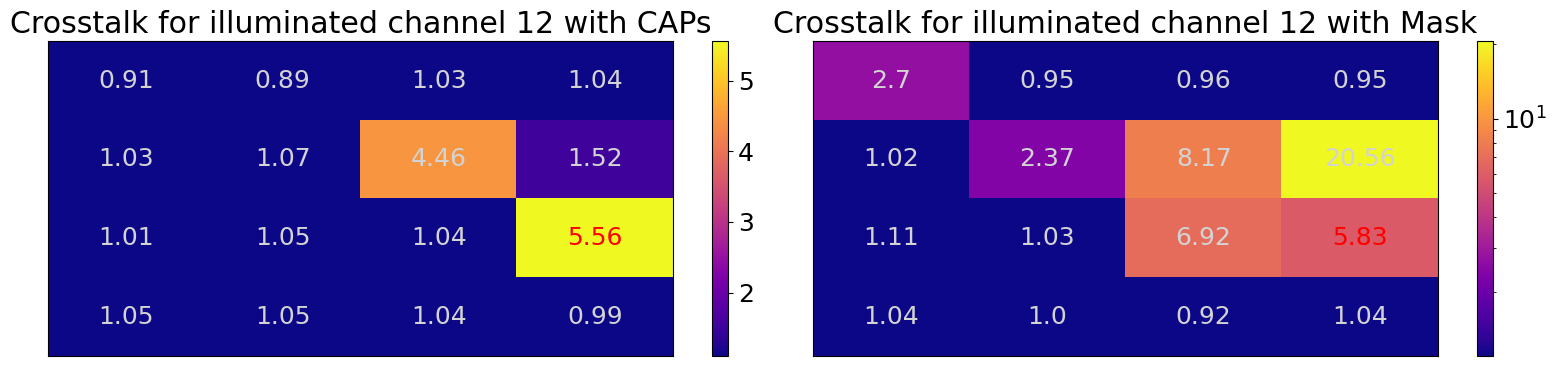

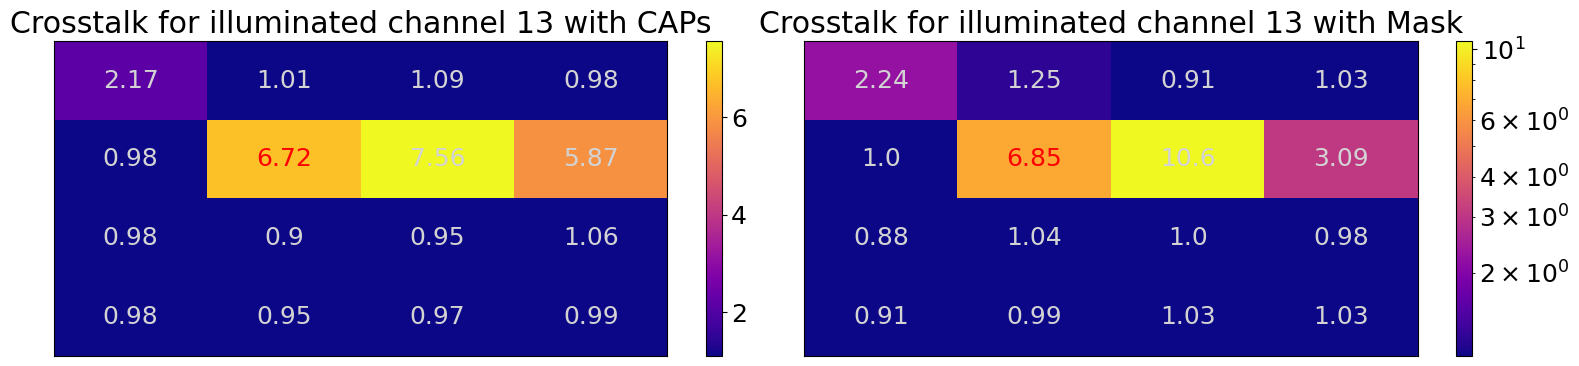

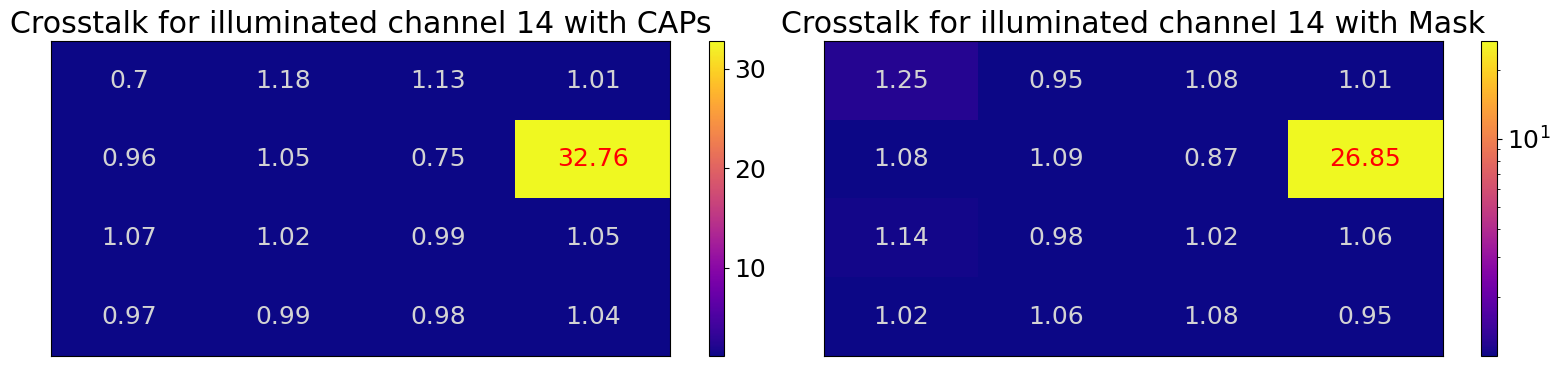

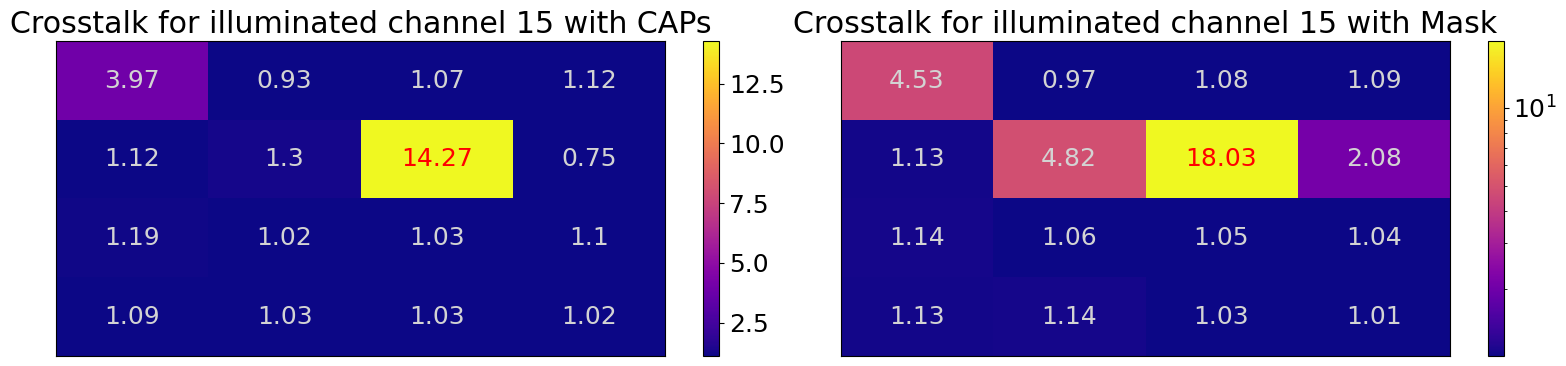

In [ ]:
import numpy as np
import matplotlib
import matplotlib as mpl
import json
import matplotlib.pyplot as plt
import os

def plot_threshold_scan(data_light, data_dark, ch, ref):
    # Convert single channel to list for uniform handling
    channels = [ch] if isinstance(ch, int) else ch

    layout = np.array([['11', '10', '09', '08'],
                        ['00', '13', '15', '14'],
                        ['05', '02', '01', '12'],
                        ['04', '03', '06', '07']])

    pe_oh = np.array([[21, 88, 147, 91],
                        [76, 102, 35, 35],
                        [23, 24, 29, 32],
                        [90, 33, 23, 83]])    

    pe_one = np.array([[23, 94, 152, 97],
                        [83, 108, 40, 37],
                        [29, 32, 36, 40],
                        [97, 39, 30, 90]]) 

    pe_two = np.array([[26, 100, 161, 108],
                        [89, 117, 37, 40],
                        [37, 41, 46, 48],
                        [105, 49, 38, 101]]) 

    pe_three = np.array([[29, 105, 171, 117],
                        [96, 124, 60, 43],
                        [46, 49, 56, 56],
                        [113, 58, 47, 111]]) 

    offset = np.array([[0, 1, 2, 1],
                        [1, 1, 0, 0],
                        [0, 0, 0, 0],
                        [1, 0, 0, 1]]) 
    # plt.figure(figsize=(16, 10))
    # plt.rcParams.update({'font.size': 18})
    
    
    ratio_map = []
    for k in range(4):
        #mean = []
        rates= []
        for l in range(4):
            for channel in channels:
                if layout[k,l] != str(channel).zfill(2):
                    continue
                factor = []
                rates_light = np.array(data_light['rates'][channel])
                rates_dark = np.array(data_dark['rates'][channel])
                for i in np.arange(0, 128, 1):
                    if i != (pe_two[k,l] - offset[k,l]*64):
                        continue
                    #if not np.isnan(rates_light[i]) and not np.isnan(rates_dark[i]) and rates_dark[i]>0 and rates_light[i]>0:
                    #    print(i)
                    rates.append(round(rates_light[i] / rates_dark[i], 2))

                        #print(layout[k,l], round(rates_light[i] / rates_dark[i], 2))
            # for rate in rates:
            #     if not np.isnan(rate) and rate !=0 and np.isfinite(rate):
            #         factor.append(rate)
            #     else:
            #         factor.append(0)
        #mean.append((rates))
        #print(rates)
        ratio_map.append(rates)

    #print(rates)
    #ratio_map = {str(i).zfill(2): rates[i] for i in range(len(rates))}
    
    # Create ratio array using vectorized operations
    #ratio = np.vectorize(lambda x: ratio_map.get(x, 1))(layout)
    ratio = ratio_map
    #print(ratio)
    return ratio

channels = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]

layout = np.array([['11', '10', '09', '08'],
                        ['00', '13', '15', '14'],
                        ['05', '02', '01', '12'],
                        ['04', '03', '06', '07']])
result = []

for a in range(16):
    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16, 4))
    number = str(a).zfill(2)
    with open(f'scans/crosstalk/20.04/SSB0_ch{number}_dark.json', 'r') as f_dark, open(f'scans/crosstalk/20.04/SSB0_ch{number}.json', 'r') as f_light:
        data_dark = json.load(f_dark)
        data_light = json.load(f_light)
        ratio_cap = plot_threshold_scan(data_light, data_dark, channels, number)

    if np.max(ratio_cap) > 1000:
        norm1 = 'log'
    else:
        norm1 = 'linear'
    im1 = ax1.imshow(ratio_cap, cmap='plasma', aspect='auto', norm= norm1, vmin=1.1)
    ticks =[]
    ax1.set_xticks(ticks)
    ax1.set_yticks(ticks)

    for i in range(4):
        for j in range(4):
            if layout[i,j] == str(int(number)).zfill(2):
                text = ax1.text(j, i, ratio_cap[i][j], ha="center", va="center", color="r")
            else:
                text = ax1.text(j, i, ratio_cap[i][j], ha="center", va="center", color="lightgrey")
    ax1.set_title(f"Crosstalk for illuminated channel {number} with CAPs")
    plt.colorbar(im1, ax=ax1)

    with open(f'scans/crosstalk/20.04_mask/SSB0_ch{number}_dark.json', 'r') as f_dark, open(f'scans/crosstalk/20.04_mask/SSB0_ch{number}.json', 'r') as f_light:
        data_dark = json.load(f_dark)
        data_light = json.load(f_light)
        ratio_mask = plot_threshold_scan(data_light, data_dark, channels, number)

    if np.max(ratio_mask)>1000:
        norm2 = 'log'
    else:
        norm2 = 'linear'
    im2 = ax2.imshow(ratio_mask, cmap='plasma', aspect='auto', norm= norm2, vmin=1.1)
    ticks =[]
    ax2.set_xticks(ticks)
    ax2.set_yticks(ticks)

    for i in range(4):
        for j in range(4):
            if layout[i,j] == str(int(number)).zfill(2):
                text = ax2.text(j, i, ratio_mask[i][j], ha="center", va="center", color="r")
            else:
                text = ax2.text(j, i, ratio_mask[i][j], ha="center", va="center", color="lightgrey")
    ax2.set_title(f"Crosstalk for illuminated channel {number} with Mask")
    plt.colorbar(im2, ax=ax2)
    fig.tight_layout()
    plt.show()                     


In [43]:
import json
import matplotlib.pyplot as plt
import numpy as np

def plateau_finder(data, ch, steps=1):
    """
    Read threshold_Scan15122025.json and plot rates[ch] vs th[ch]
    
    Args:
        data: dictionary containing 'th' and 'rates' keys with lists of lists
        ch: integer or list of integers representing channel numbers
    """    
    # Convert single channel to list for uniform handling
    channels = [ch] if isinstance(ch, int) else ch
    
    threshold = {}
    rates= {}
    plateau = [] 
#    plt.figure(figsize=(16, 10))
#    plt.rcParams.update({'font.size': 18})

    for channel in channels:
        threshold =data['th'][channel]
        rates= data['rates'][channel]
        maximum = np.argmax(rates[:64])
        last_rate = np.max(rates)
        for index in np.arange(maximum+1, len(threshold), steps):
            current_rate = rates[index]
            if (last_rate - current_rate) < (0.1*last_rate):

                print("Ansatz Plateau for channel", channel,": ", index)
            last_rate = current_rate    

#    plt.xlabel('Threshold (th)')
#    plt.ylabel('Rates')
#    plt.legend()
        

#    plt.xticks(np.arange(0, 256, 5), rotation=45)
    #plt.xlim(120, 191)
    #plt.xlim(100, 170)
#    plt.yscale('log')
#    plt.grid(True)
#    plt.show()


channels =[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]
with open('/home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/scans/SSB0/combined_scans_13_03_2026_16-27-53/tth.json', 'r') as f:
    data = json.load(f)
    plateau_finder(data, channels)

Ansatz Plateau for channel 0 :  32
Ansatz Plateau for channel 0 :  33
Ansatz Plateau for channel 0 :  34
Ansatz Plateau for channel 0 :  35
Ansatz Plateau for channel 0 :  40
Ansatz Plateau for channel 0 :  42
Ansatz Plateau for channel 0 :  45
Ansatz Plateau for channel 0 :  47
Ansatz Plateau for channel 0 :  49
Ansatz Plateau for channel 0 :  56
Ansatz Plateau for channel 0 :  61
Ansatz Plateau for channel 0 :  63
Ansatz Plateau for channel 1 :  29
Ansatz Plateau for channel 1 :  31
Ansatz Plateau for channel 1 :  32
Ansatz Plateau for channel 1 :  33
Ansatz Plateau for channel 1 :  38
Ansatz Plateau for channel 1 :  40
Ansatz Plateau for channel 1 :  42
Ansatz Plateau for channel 1 :  45
Ansatz Plateau for channel 1 :  47
Ansatz Plateau for channel 1 :  49
Ansatz Plateau for channel 1 :  51
Ansatz Plateau for channel 1 :  56
Ansatz Plateau for channel 1 :  57
Ansatz Plateau for channel 2 :  22
Ansatz Plateau for channel 2 :  25
Ansatz Plateau for channel 2 :  27
Ansatz Plateau for c

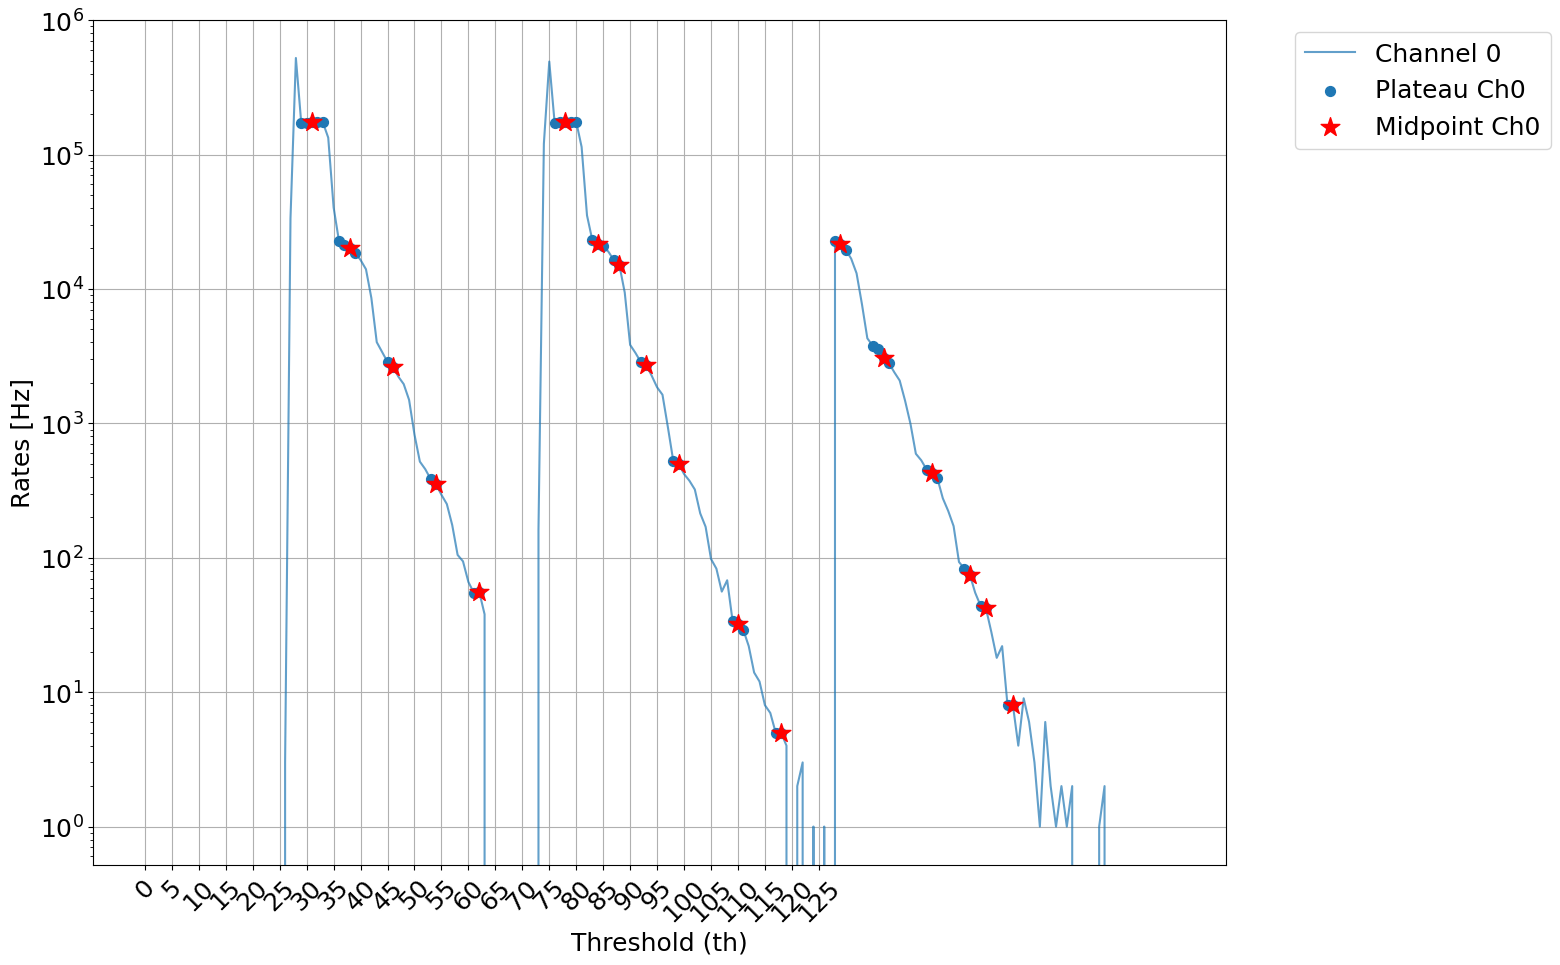


SUMMARY OF PLATEAUS AND MIDPOINTS

Channel 0:
----------------------------------------
  Plateau 1:
    Range: thresholds 29.0 - 33.0 (indices 29 - 33)
    Midpoint: threshold = 31.0, threshold (MIDAS) = 32.0
  Plateau 2:
    Range: thresholds 36.0 - 39.0 (indices 36 - 39)
    Midpoint: threshold = 38.0, threshold (MIDAS) = 25.0
  Plateau 3:
    Range: thresholds 45.0 - 46.0 (indices 45 - 46)
    Midpoint: threshold = 46.0, threshold (MIDAS) = 17.0
  Plateau 4:
    Range: thresholds 53.0 - 54.0 (indices 53 - 54)
    Midpoint: threshold = 54.0, threshold (MIDAS) = 9.0
  Plateau 5:
    Range: thresholds 61.0 - 62.0 (indices 61 - 62)
    Midpoint: threshold = 62.0, threshold (MIDAS) = 1.0
  Plateau 6:
    Range: thresholds 76.0 - 80.0 (indices 76 - 80)
    Midpoint: threshold = 78.0, threshold (MIDAS) = -15.0
  Plateau 7:
    Range: thresholds 83.0 - 85.0 (indices 83 - 85)
    Midpoint: threshold = 84.0, threshold (MIDAS) = -21.0
  Plateau 8:
    Range: thresholds 87.0 - 88.0 (indices 87

In [16]:
import json
import matplotlib.pyplot as plt
import numpy as np

def plateau_finder(data, ch, steps=1):
    """
    Read threshold_Scan15122025.json and plot rates[ch] vs th[ch]
    
    Args:
        data: dictionary containing 'th' and 'rates' keys with lists of lists
        ch: integer or list of integers representing channel numbers
    """    
    # Convert single channel to list for uniform handling
    channels = [ch] if isinstance(ch, int) else ch
    
    # Dictionary to store plateau indices for each channel
    plateaus = {}
    # Dictionary to store plateau midpoints for each channel
    plateau_midpoints = {}
    
    plt.figure(figsize=(16, 10))
    plt.rcParams.update({'font.size': 18})

    for channel in channels:
        threshold = data['th'][channel]
        rates = data['rates'][channel]
        #maximum = np.argmax(rates[:64])
        last_rate = rates[0]
        
        # Store plateau indices for this channel
        channel_plateaus = []
        first_plateau_value = True
        for index in np.arange(0, len(threshold), steps):
            current_rate = rates[index]
            if (-0.1 * last_rate) < (last_rate - current_rate) < (0.1 * last_rate):
                #print("Ansatz Plateau for channel", channel, ": ", index)
                if first_plateau_value == True:
                    channel_plateaus.append(index-1)
                    first_plateau_value= False
                channel_plateaus.append(index)
            else:
                first_plateau_value=True
            last_rate = current_rate
        
        # Store plateaus for this channel
        plateaus[channel] = channel_plateaus
        
        # Find plateau midpoints
        channel_midpoints = []
        if channel_plateaus:
            # Group consecutive indices into plateaus
            plateau_groups = []
            current_group = []
            
            for idx in sorted(set(channel_plateaus)):  # Use set to remove duplicates, then sort
                if not current_group or idx == current_group[-1] + steps:
                    current_group.append(idx)
                else:
                    if len(current_group) > 1:  # Only consider groups with more than one point
                        plateau_groups.append(current_group)
                    current_group = [idx]
            
            # Add the last group if it has more than one point
            if len(current_group) > 1:
                plateau_groups.append(current_group)
            
            # Calculate midpoint for each plateau group
            for group in plateau_groups:
                midpoint_index = group[len(group) // 2]
                midpoint_threshold = threshold[midpoint_index]
                midpoint_rate = rates[midpoint_index]
                channel_midpoints.append({
                    'threshold': midpoint_threshold,
                    'rate': midpoint_rate,
                    'index': midpoint_index,
                    'start_index': group[0],
                    'end_index': group[-1],
                    'start_threshold': threshold[group[0]],
                    'end_threshold': threshold[group[-1]]
                })
        
        plateau_midpoints[channel] = channel_midpoints
        
        # Plot the rate curve for this channel
        plt.plot(threshold, rates, label=f'Channel {channel}', alpha=0.7)
        
        # Plot plateau points if any were found
        if channel_plateaus:
            plateau_thresholds = [threshold[i] for i in channel_plateaus]
            plateau_rates = [rates[i] for i in channel_plateaus]
            plt.scatter(plateau_thresholds, plateau_rates, s=50, zorder=5, 
                       label=f'Plateau Ch{channel}' if channel in channels else "")
            
            # Plot midpoints with different markers
            if channel_midpoints:
                midpoint_thresholds = [m['threshold'] for m in channel_midpoints]
                midpoint_rates = [m['rate'] for m in channel_midpoints]
                plt.scatter(midpoint_thresholds, midpoint_rates, s=200, marker='*', 
                           color='red', zorder=10, 
                           label=f'Midpoint Ch{channel}' if channel in channels else "")

    plt.xlabel('Threshold (th)')
    plt.ylabel('Rates [Hz]')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.xticks(np.arange(0, 128, 5), rotation=45)
    #plt.xlim(120, 191)
    #plt.xlim(100, 170)
    plt.yscale('log')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return plateaus, plateau_midpoints


channels = [0] #[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
with open('/home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/scans/Mutrig4_SSB0_tth.json', 'r') as f:
    data = json.load(f)
    plateaus, plateau_midpoints = plateau_finder(data, channels)

# Print all plateau values and midpoints
print("\n" + "="*80)
print("SUMMARY OF PLATEAUS AND MIDPOINTS")
print("="*80)

for ch in channels:
    print(f"\nChannel {ch}:")
    print("-" * 40)
    
    if ch in plateau_midpoints and plateau_midpoints[ch]:
        for i, midpoint in enumerate(plateau_midpoints[ch]):
            print(f"  Plateau {i+1}:")
            print(f"    Range: thresholds {midpoint['start_threshold']:.1f} - {midpoint['end_threshold']:.1f} "
                  f"(indices {midpoint['start_index']} - {midpoint['end_index']})")
            print(f"    Midpoint: threshold = {midpoint['threshold']:.1f}, "
                  f"threshold (MIDAS) = {63- midpoint['threshold']:.1f}")
    else:
        print("  No plateaus found")

# Also print a compact summary table
print("\n" + "="*80)
print("COMPACT SUMMARY - MIDPOINT THRESHOLDS")
print("="*80)
print(f"{'Channel':<8} {'Plateau':<8} {'Threshold':<12} {'Rate (Hz)':<12} {'Range':<20}")
print("-"*60)

for ch in channels:
    if ch in plateau_midpoints and plateau_midpoints[ch]:
        for i, midpoint in enumerate(plateau_midpoints[ch]):
            range_str = f"{midpoint['start_threshold']:.1f}-{midpoint['end_threshold']:.1f}"
            print(f"{ch:<8} {i+1:<8} {midpoint['threshold']:<12.1f} {midpoint['rate']:<12.1f} {range_str:<20}")
    else:
        print(f"{ch:<8} {'No plateaus':<8}")

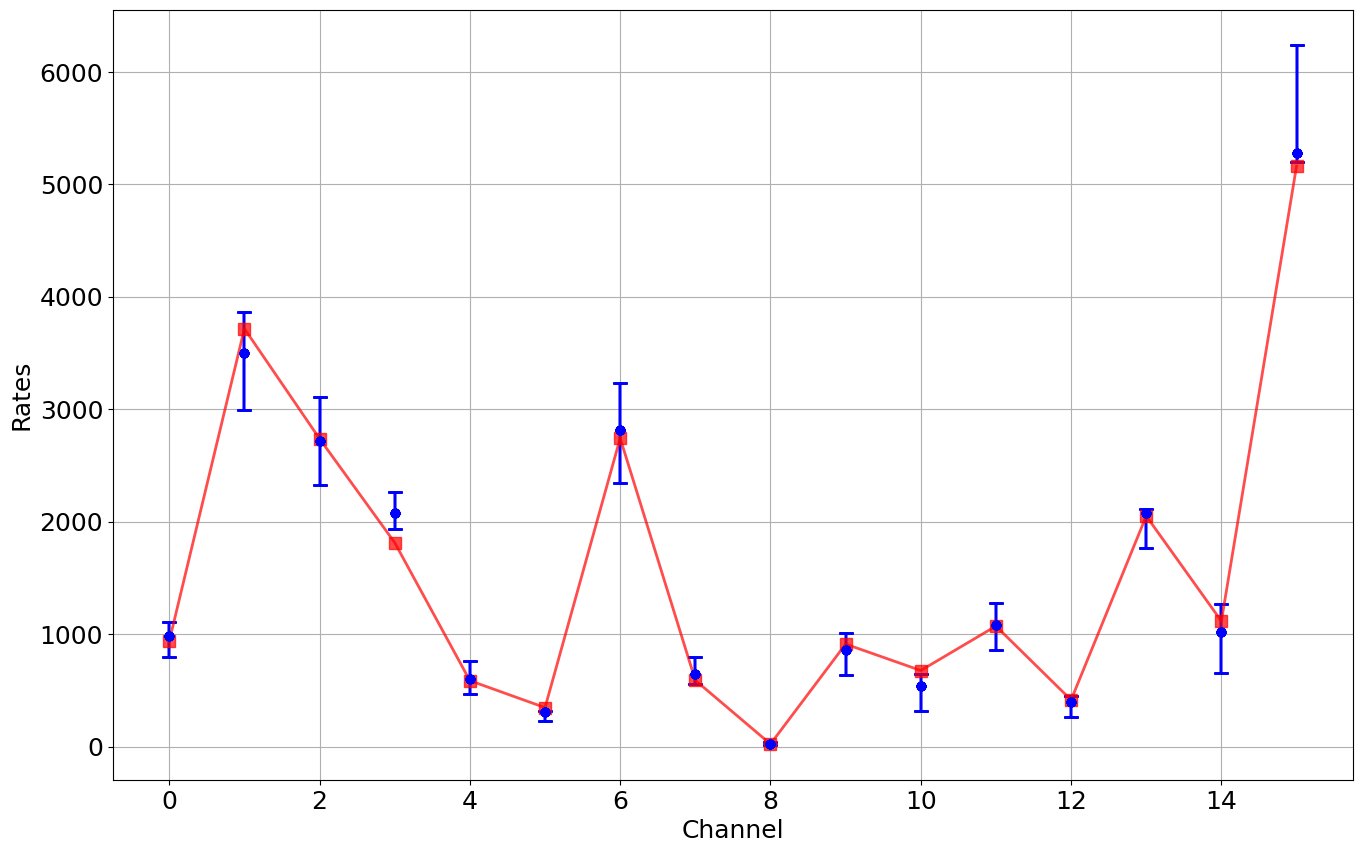

Channel 0: 986.0 Hz +/- 11.97 %/ 18.86% 
Channel 1: 3502.0 Hz +/- 10.45 %/ 14.59% 
Channel 2: 2721.0 Hz +/- 14.19 %/ 14.41% 
Channel 3: 2076.0 Hz +/- 8.86 %/ 6.84% 
Channel 4: 598.0 Hz +/- 26.59 %/ 21.24% 
Channel 5: 308.0 Hz +/- 3.9 %/ 25.32% 
Channel 6: 2819.0 Hz +/- 14.54 %/ 16.89% 
Channel 7: 647.0 Hz +/- 23.18 %/ 14.68% 
Channel 8: 24.0 Hz +/- 66.67 %/ 33.33% 
Channel 9: 859.0 Hz +/- 17.81 %/ 26.31% 
Channel 10: 536.0 Hz +/- 20.52 %/ 41.79% 
Channel 11: 1085.0 Hz +/- 17.24 %/ 20.65% 
Channel 12: 398.0 Hz +/- 13.82 %/ 33.92% 
Channel 13: 2075.0 Hz +/- 1.98 %/ 15.13% 
Channel 14: 1020.0 Hz +/- 24.02 %/ 35.98% 
Channel 15: 5274.0 Hz +/- 18.34 %/ 1.37% 


In [14]:
import pandas as pd
def stability_check(data, tth, offset, csv_file=None):   
    
    rate = []
    upper = []
    lower = []

    for i in range(16):
        tth_value = 63-tth[i] + offset[i]*64
        rate_value = data['rates'][i][tth_value]
        rate.append(rate_value)
        rate_value_plus = data['rates'][i][tth_value+1]
        upper.append(abs(rate_value_plus-rate_value))
        rate_value_minus = data['rates'][i][tth_value-1]
        lower.append(abs(rate_value-rate_value_minus))
    
    plt.figure(figsize=(16, 10))
    plt.rcParams.update({'font.size': 18})

    for channel in channels:
        plt.errorbar(range(16), rate, yerr=[lower, upper],  label=f'Channel {channel}',fmt='o', capsize=5, color='blue')
    
    plt.xlabel('Channel')
    plt.ylabel('Rates')
    #plt.legend()
    
    #plt.vlines(ref, 0, 10**6, color='k')
    #plt.xticks(np.arange(0, 256, 5), rotation=45)
    #plt.xlim(120, 191)
    #plt.xlim(0, 63)
    #plt.yscale('log')
    #plt.grid(True)
    #plt.show()
    
    if csv_file is not None:
        try:
            # Read CSV file
            df = pd.read_csv(csv_file)
            
            # Extract X (channel) and Y (rate) values
            csv_channels = df['X'].values
            csv_rates = df['Y'].values
            
            # Filter only channels 0-15
            mask = csv_channels < 16
            csv_channels_filtered = csv_channels[mask]
            csv_rates_filtered = csv_rates[mask]
            
            # Plot reference data
            plt.plot(csv_channels_filtered, csv_rates_filtered, 
                    's-', label='Reference (CSV)', color='red', 
                    markersize=8, linewidth=2, alpha=0.7)
        except Exception as e:
            print(f"Error reading CSV file: {e}")
    plt.grid(True)
    plt.show()
    return rate, upper, lower



tth = [35, 27, 27, 32, 38, 36, 24, 33, 36, 44, 35, 25, 32, 32, 26, 31]
offset = [1, 1, 0, 1, 2, 2, 0, 1, 1, 2, 2, 1, 2, 1, 1, 1]
with open('/home/mu3e/git-repos/online_chipQA/online/userfiles/sequencer/MutrigTB/ThresholdScans/scans/Mutrig4_SSB0_tth-1.json', 'r') as f:
    data = json.load(f)
    rate, upper, lower = stability_check(data, tth, offset, csv_file='/home/mu3e/measurements/SingleMutrigChip/Rate Hitmap-20260518-131740.csv')
    for i in range(16):
        print(f"Channel {i}: {rate[i]} Hz +/- {np.round(upper[i]/rate[i]*100,2)} %/ {np.round(100*lower[i]/rate[i],2)}% ")